# Analysis of the Allegheny County Jail Oversight Board Meeting Minutes

- Contributor: Matteo Secomandi
- AI Acknowledgements: Gemini used for debugging

## N-gram Analysis

This notebook contains code that performs n-gram analysis of pre-processed JOB meeting minutes text.

### Import libraries and lemmatized text data:

In [2]:
import numpy as np
import pandas as pd
import spacy
from collections import Counter
import matplotlib.pyplot as plt

# Set up paths, taken from preprocessing notebooks
from pathlib import Path

BASE = Path("..").resolve()
OUT_DIR = BASE / "Data" / "Text" # where lemmatized text is stored

path = OUT_DIR / 'lemmatized_text.xz'

# Adapted from UDA Clustering on Text.ipynb
import pickle

with open(path, 'rb') as f:
    documents = pickle.load(f)

print(f'Number of documents: {len(documents)}')
print(documents[0])

Number of documents: 156
['monthly', 'thursday', 'october', '2012', 'house', '4:00', 'p.m.', 'chief', 'defender', 'rich', 'charles', 'sheriff', 'major', 'interested', 'discuss', 'request', 'discuss', 'role', 'concentrate', 'library', 'learning', 'teaching', 'read', 'provide', 'brochure', 'pa', 'prison', 'society', 'supreme', 'rule', 'state', 'pay', 'september', '2012', 'newspaper', 'confinement', 'confine', 'hour', 'solitary', 'confinement', 'solitary', 'confinement', 'finally', 'acting', 'stickman', 'permit', 'voting', 'absentee', 'ballot', 'misdemeanor', 'september', '2012', 'discuss', 'attend', 're-', 'entry', 'state', 'attend', 'sec', 'john', 'wetzel', 'chief', 'probation', 'potinger', 'david', 'hichton', 'u.s.', 'attorney', 'keynote', 'speaker', 'welcome', 'new', 'state', 'promotion', 'warren', 'deputy', 'services', 'program', 'services', 'old', 'naacp', 'floor', 'collect', 'absentee', 'ballot', 'inmates', 'yesterday', 'new', 'correctional', 'health', 'services', 'month', 'collabo

### Data has been loaded in successfully. By looking at the first document, we can see that some date information is included at the start. We begin by testing to see if we can easily extract this information from documents by looking at first couple words. We also address the blank documents issue that was identified by this process.

In [3]:
empty_docs = []

i = 0 # Tracking document indicies in order to manually inspect outliers and track empty docs

for document in documents:
    # Added indicies until almost all had date information
    print(i, document[0:15])
    # Filter for empty_docs
    if len(document) == 0:
        empty_docs.append(i)
    i += 1

empty_docs # We probably want to remove these from analysis

0 ['monthly', 'thursday', 'october', '2012', 'house', '4:00', 'p.m.', 'chief', 'defender', 'rich', 'charles', 'sheriff', 'major', 'interested', 'discuss']
1 ['monthly', 'thursday', 'november', '2012', 'house', '4:00', 'p.m.', 'rich', 'charles', 'sheriff', 'deputy', 'warren', 'major', 'interested', 'discuss']
2 ['monthly', 'thursday', 'december', '2012', 'house', '4:00', 'p.m.', 'sheriff', 'rich', 'charles', 'chief', 'defender', 'deputy', 'warren', 'major']
3 ['monthly', 'thursday', 'march', '2013', 'house', '4:00', 'p.m.', 'sheriff', 'p.', 'rich', 'genie', 'beckom', 'charles', 'deputy', 'monica']
4 ['monthly', 'thursday', '2012', 'house', '4:00', 'p.m.', 'kim', 'charles', 'chief', 'rizzo', 'sheriff', 'acting', 'stickman', 'iii', 'major']
5 ['monthly', 'thursday', 'june', '2012', 'house', '4:00', 'p.m.', 'chief', 'defender', 'rich', 'walt', 'szymanski', 'charles', 'chief', 'rizzo']
6 ['monthly', 'thursday', 'september', '2012', 'house', '4:00', 'p.m.', 'chief', 'defender', 'rich', 'char

[]

### Looking at the distribution of document lengths, it looks like it is heavily left-skewed. It might be interesting to see which of the documents are the super long ones.

There are 156 non-empty documents


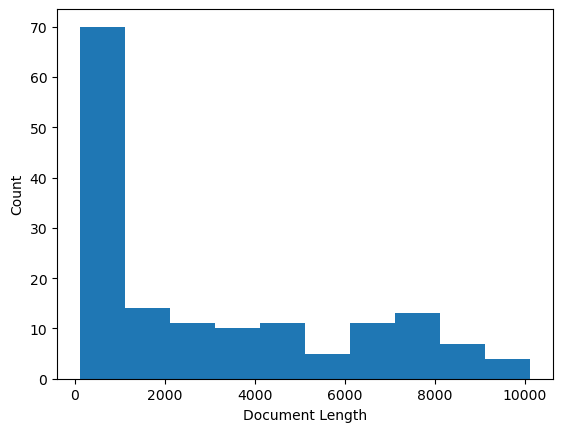

The median document length is 1743.5


In [4]:
# Creating new list of non-empty documents
docs_clean = [documents[i] for i in range(len(documents)) if i not in empty_docs]
print(f'There are {len(docs_clean)} non-empty documents')

# We are also interested in seeing the length of the non-empty docs to see if they are dramatically different
doc_lengths = [len(doc) for doc in docs_clean]
plt.hist(doc_lengths)
plt.xlabel("Document Length")
plt.ylabel("Count")
plt.show()

print(f'The median document length is {pd.Series(doc_lengths).median()}')

In [5]:
# We want to extract the date information from the documents
years = [str(y) for y in range(2012, 2027)]

doc_years = []
no_dates = []
i = 0 

for doc in docs_clean:
    date_string = ''.join(doc[0:15])
    found_year = None
    for year in years:
        if year in date_string:
            found_year = year
            break

    if found_year is None:
        no_dates.append(i)
        doc_years.append(np.nan)
    else:
        doc_years.append(int(found_year))
    i += 1

for i in no_dates:
    print(i, len(docs_clean[i]), docs_clean[i]) # We probably want to find some manual way to add dates or remove

47 513 ['monthly', 'thursday', 'december', '7th', '4:00', 'pm', 'courthouse', 'david', 'controller', 'sheriff', 'ken', 'varhola', 'council', 'john', 'abass', 'kamara', 'attend', 'deputy', 'monica', 'prison', 'society', 'interested', 'newspaper', 'ad', 'time', 'correctional', 'position', 'pg', 'article', 'discuss', 'lawsuit', 'correctional', 'topic', 'mandatory', 'overtime', 'topic', 'pregnant', 'woman', 'segregation', 'solitary', 'note', 'express', 'concern', 'matter', 'recent', 'lawsuit', 'subject', 'regard', 'lawsuit', 'note', 'settlement', 'pay', 'taxpayer', 'money', 'newspaper', 'article', 'importance', 'job', 'training', 'service', 'provide', 'important', 'role', 'play', 'help', 'employment', 'release', 'reduce', 'likelihood', 'enter', 'eighteen', 'juvenile', 'list', 'recent', 'census', 'female', 'good', 'alternative', 'housing', 'unit', 'enable', 'resident', '6,750', 'hour', 'community', 'service', 'commend', 'express', 'confusion', 'regard', 'medical', 'list', 'total', 'pregnant

In [6]:
# Looking at how many documents belong to each year
pd.Series(doc_years).value_counts(dropna=False)

2024.0    14
2025.0    13
2018.0    12
2021.0    12
2022.0    12
2023.0    12
2016.0    11
2017.0    11
2019.0    11
2013.0    10
2014.0    10
2020.0    10
2015.0     8
2012.0     6
NaN        2
2026.0     2
Name: count, dtype: int64

### Next, we create TF and TF-IDF tables to analyze the most frequently used words. The following code is heavily adopted from the HW2 solutions.

In [7]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

vocab_size = 10000

tf_vectorizer = CountVectorizer(
    analyzer='word',
    tokenizer=lambda x: x, 
    preprocessor=lambda x: x,
    token_pattern=None,
    # Arguments above this line necessary to account for the fact that our data has already been lemmatized
    max_df=0.7,
    min_df=2,
    ngram_range=(1, 3), # Looking at n-grams of size 1 to 3
    max_features=vocab_size
)

tf = tf_vectorizer.fit_transform(docs_clean)

idf_transformer = TfidfTransformer()
tfidf = idf_transformer.fit_transform(tf)

In [8]:
vocab = tf_vectorizer.get_feature_names_out()
vocab # Might be good to change pre-processing to remove %, &, •, ’ symbols 

array(['%', '% %', '% employee', ..., 'zoom', 'zuhlke', '|'], dtype=object)

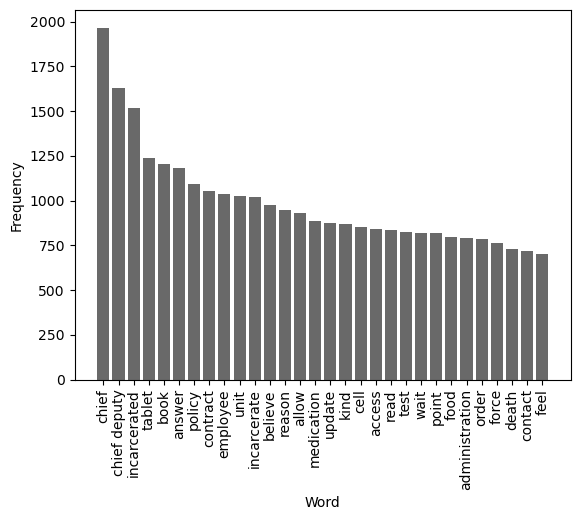

In [9]:
def get_top_words(tf_1d_table, vocab, num_top_words=20):
    return sorted(zip(tf_1d_table, vocab), reverse=True)[:num_top_words]

def print_top_words(tf_1d_table, vocab, num_top_words=20):
    sorted_tuples = get_top_words(tf_1d_table, vocab, num_top_words)

    for _, word in sorted_tuples:
        print(word, end=' ')
    print()

def plot_top_words(tf_1d_table, vocab, num_top_words=20, divide_by_sum=False):
    if divide_by_sum:
        tf_1d_table = tf_1d_table / tf_1d_table.sum()
    sorted_tuples = get_top_words(tf_1d_table, vocab, num_top_words)
    top_counts, top_words = zip(*sorted_tuples)

    plt.bar(range(num_top_words), top_counts, color='dimgray')
    plt.xticks(range(num_top_words), top_words, rotation=90)
    plt.xlabel('Word')
    plt.ylabel('Frequency')

plot_top_words(np.array(tf.sum(axis=0)).flatten(), vocab, num_top_words=30)

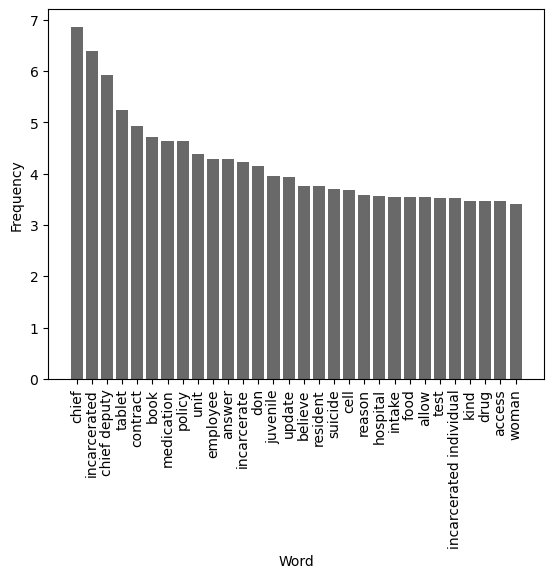

In [10]:
plot_top_words(np.array(tfidf.sum(axis=0)).flatten(), vocab, num_top_words=30)

### No immediate observations from text. We will now try to view n-gram frequency based on year and warden tenure.

In [11]:
# Adding code for identfying dates

import re

def extract_year_month(text):
    # month names
    months = {
        "january": 1, "february": 2, "march": 3, "april": 4,
        "may": 5, "june": 6, "july": 7, "august": 8,
        "september": 9, "october": 10, "november": 11, "december": 12
    }
    
    # find year
    year_match = re.search(r"\b(20\d{2})\b", text)
    year = int(year_match.group(1)) if year_match else None
    
    # find month name
    month_match = re.search(r"(january|february|march|april|may|june|july|august|september|october|november|december)", text.lower())
    month = months[month_match.group(1)] if month_match else None
    
    return year, month

year_month = [extract_year_month(' '.join(doc)) for doc in documents]
years = [ym[0] for ym in year_month]
months = [ym[1] for ym in year_month]

import pandas as pd
df = pd.DataFrame({
    "document": documents,
    "year": years,
    "month": months
})

tenure_1 = (
    (df["year"] > 2012) & (df["year"] < 2023)
) | (
    (df["year"] == 2012) & (df["month"] >= 9)
) | (
    (df["year"] == 2023) & (df["month"] <= 9)
)

tenure_2 = (
    (df["year"] == 2023) & (df["month"] >= 10)
) | (
    (df["year"] == 2024)
)

tenure_3 = df["year"] >= 2025

df["period"] = None
df.loc[tenure_1, "period"] = "Harper"
df.loc[tenure_2, "period"] = "Dady"
df.loc[tenure_3, "period"] = "Wingard"

df.year.value_counts()

year
2024    14
2025    13
2017    12
2018    12
2021    12
2022    12
2023    12
2016    11
2019    11
2013    10
2014    10
2020    10
2015     8
2012     6
2026     2
2004     1
Name: count, dtype: int64

In [12]:
# One year has been classified as 2004 we can replace this with none since it is incorrect

df.year = df.year.replace({2004:None})

df.year.value_counts(dropna=False)

year
2024    14
2025    13
2017    12
2018    12
2021    12
2022    12
2023    12
2016    11
2019    11
2013    10
2014    10
2020    10
2015     8
2012     6
2026     2
None     1
Name: count, dtype: int64

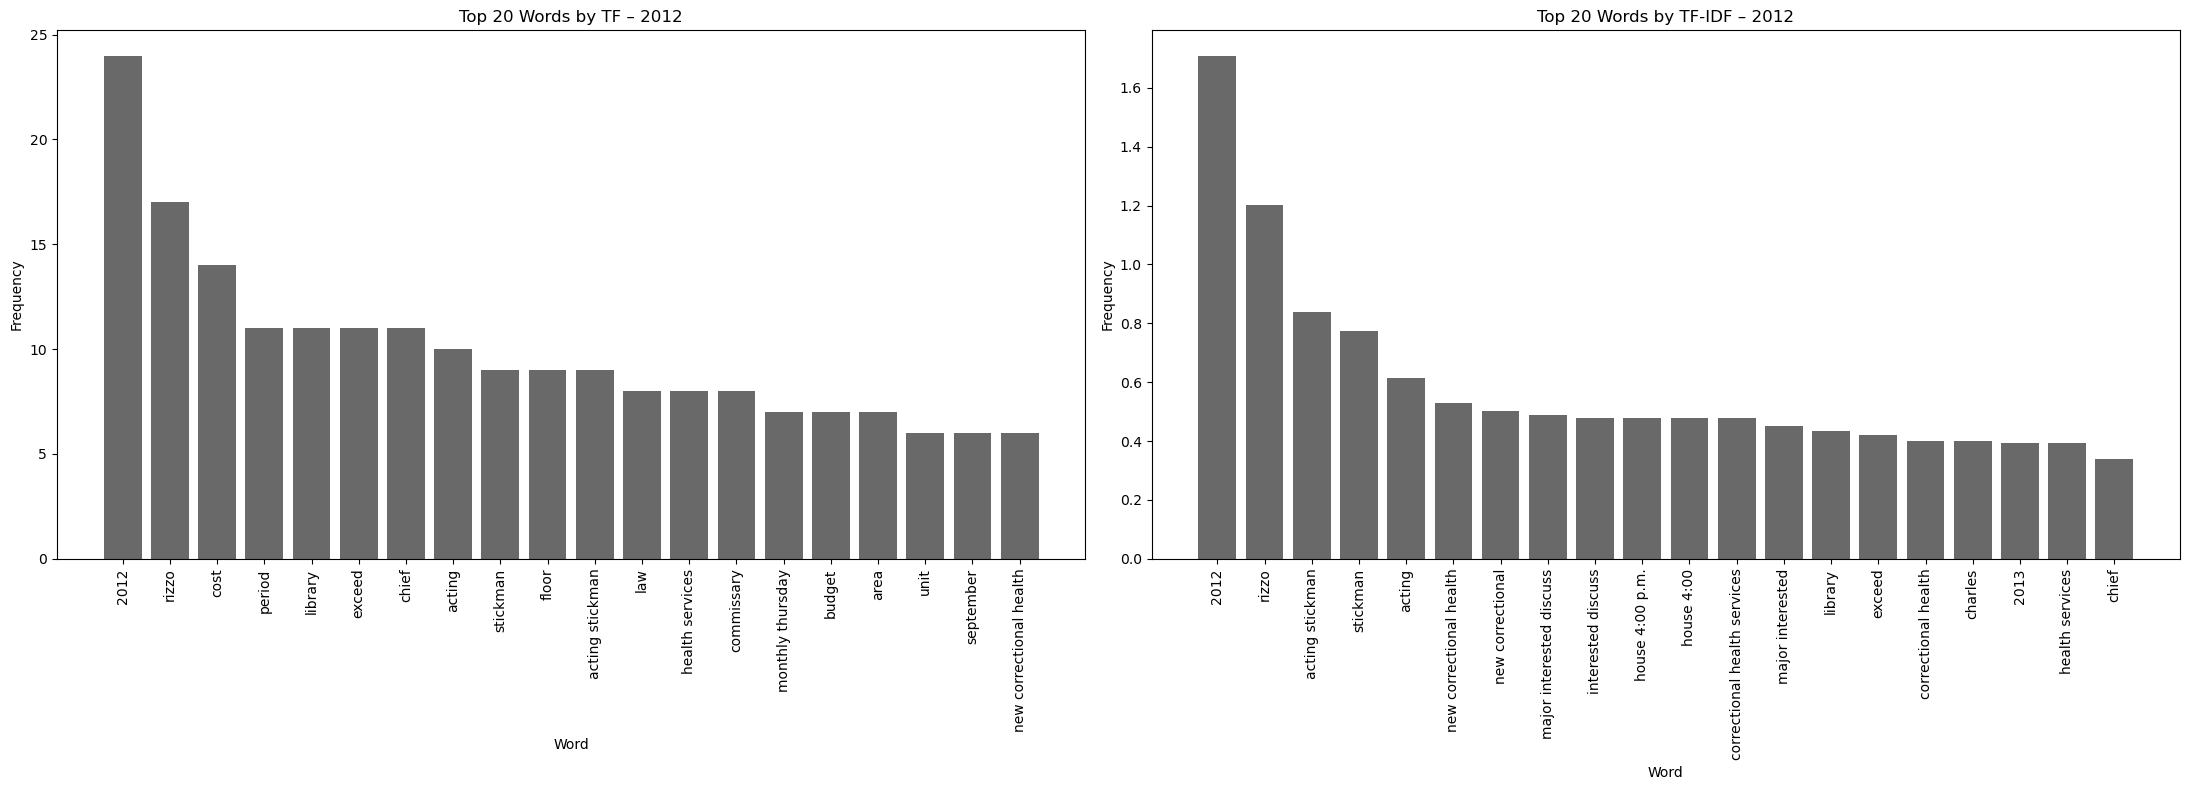

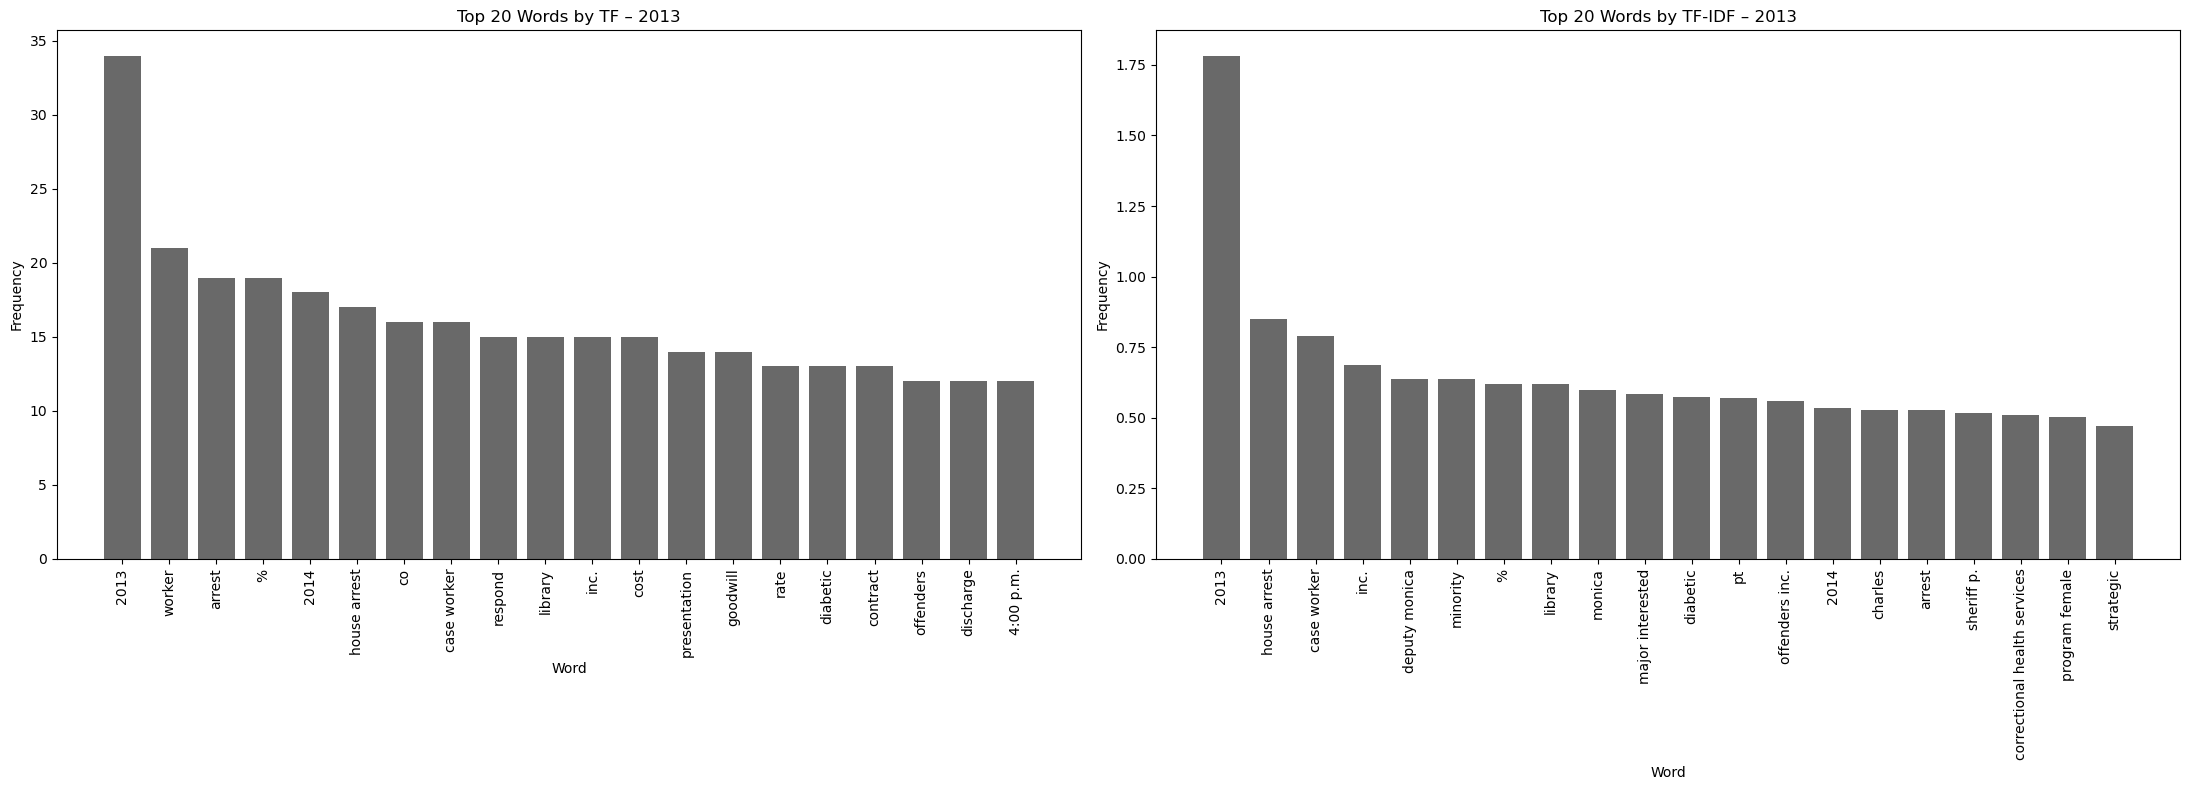

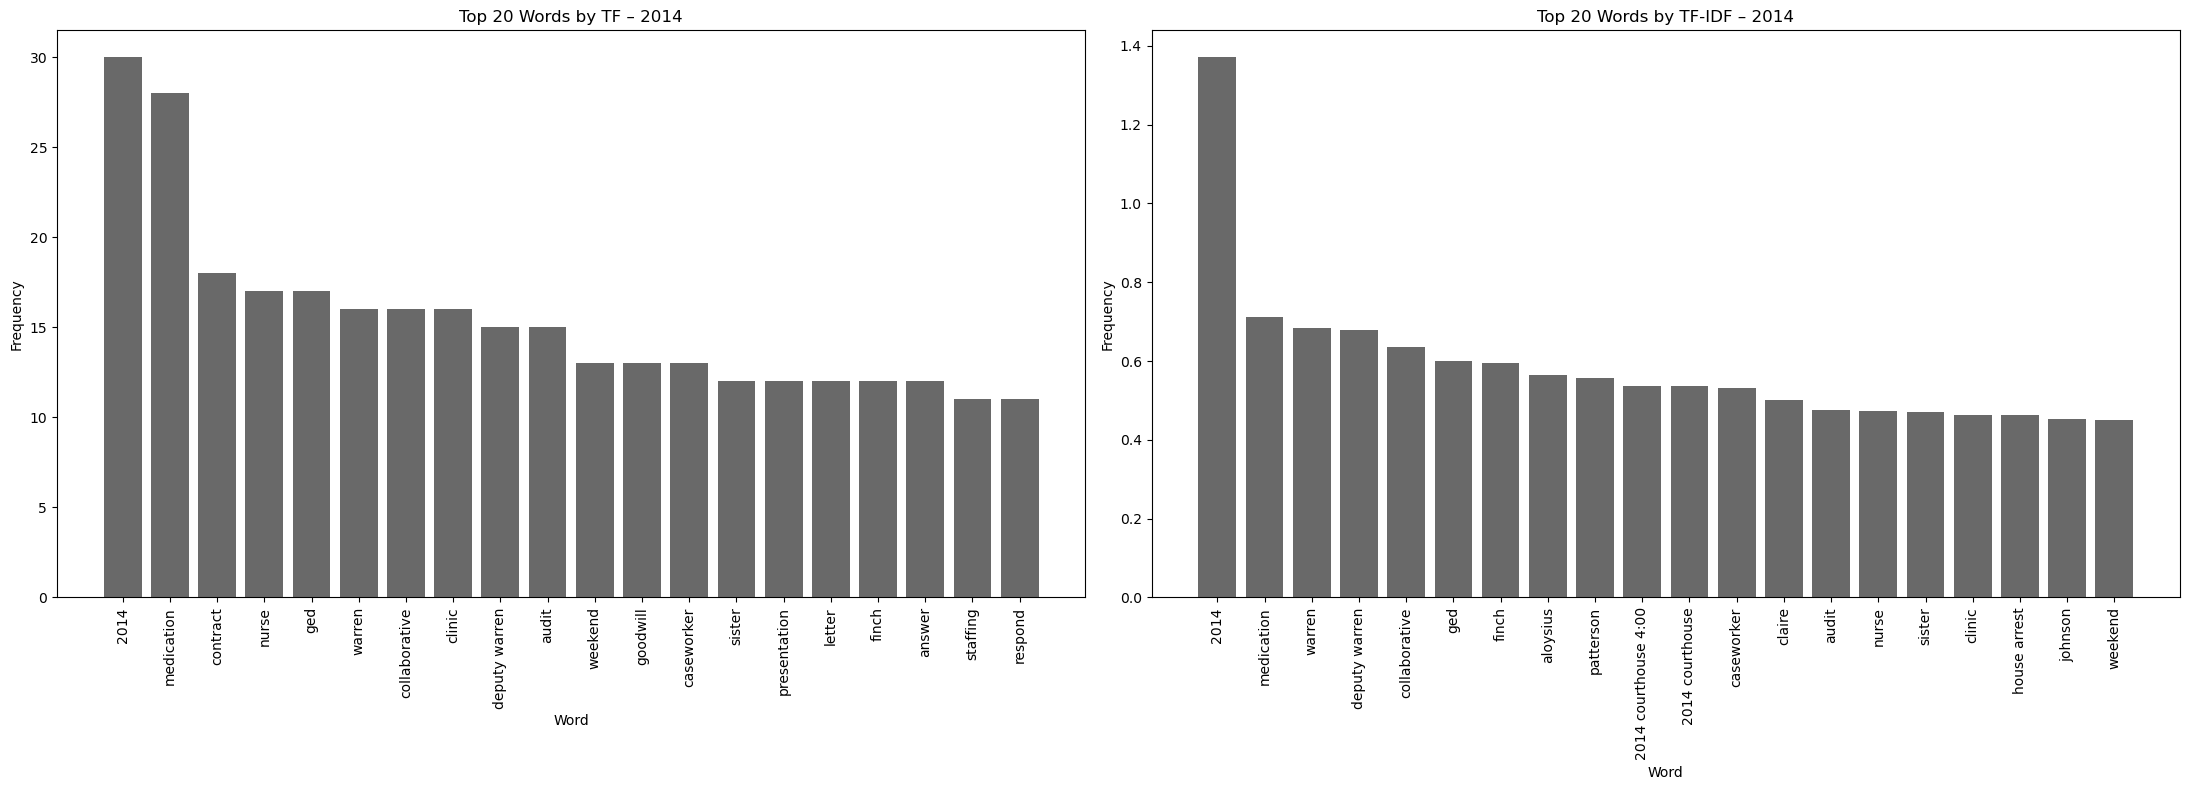

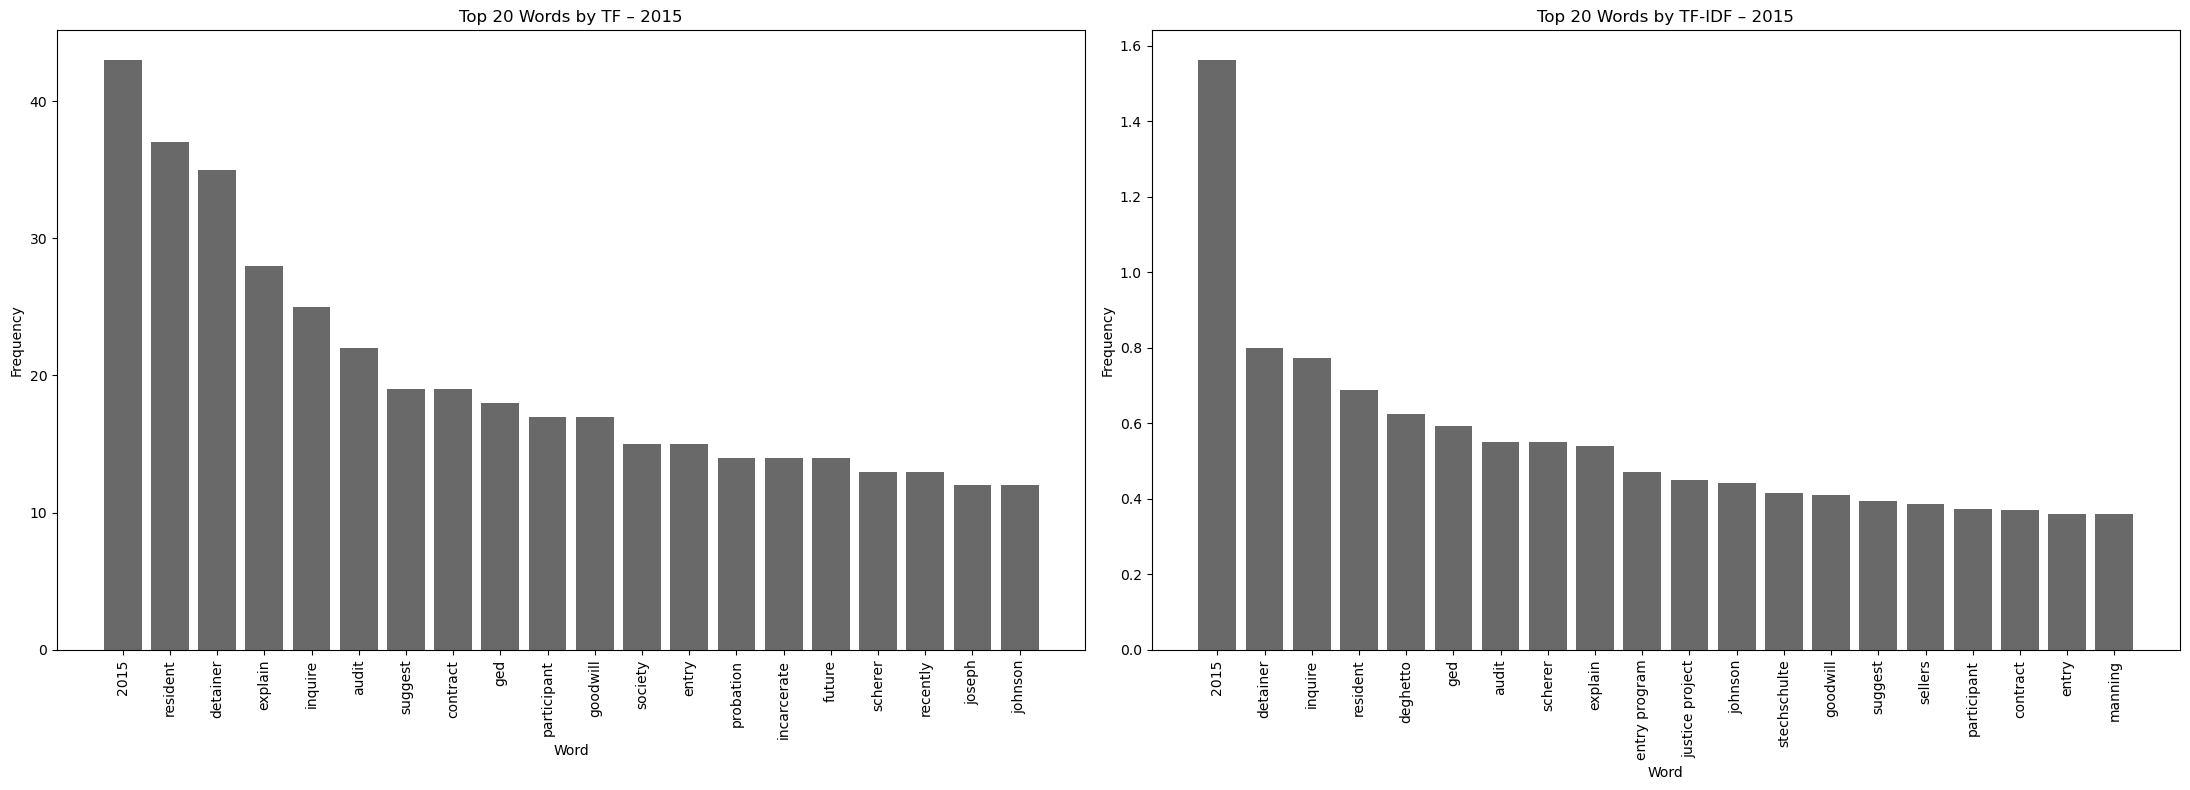

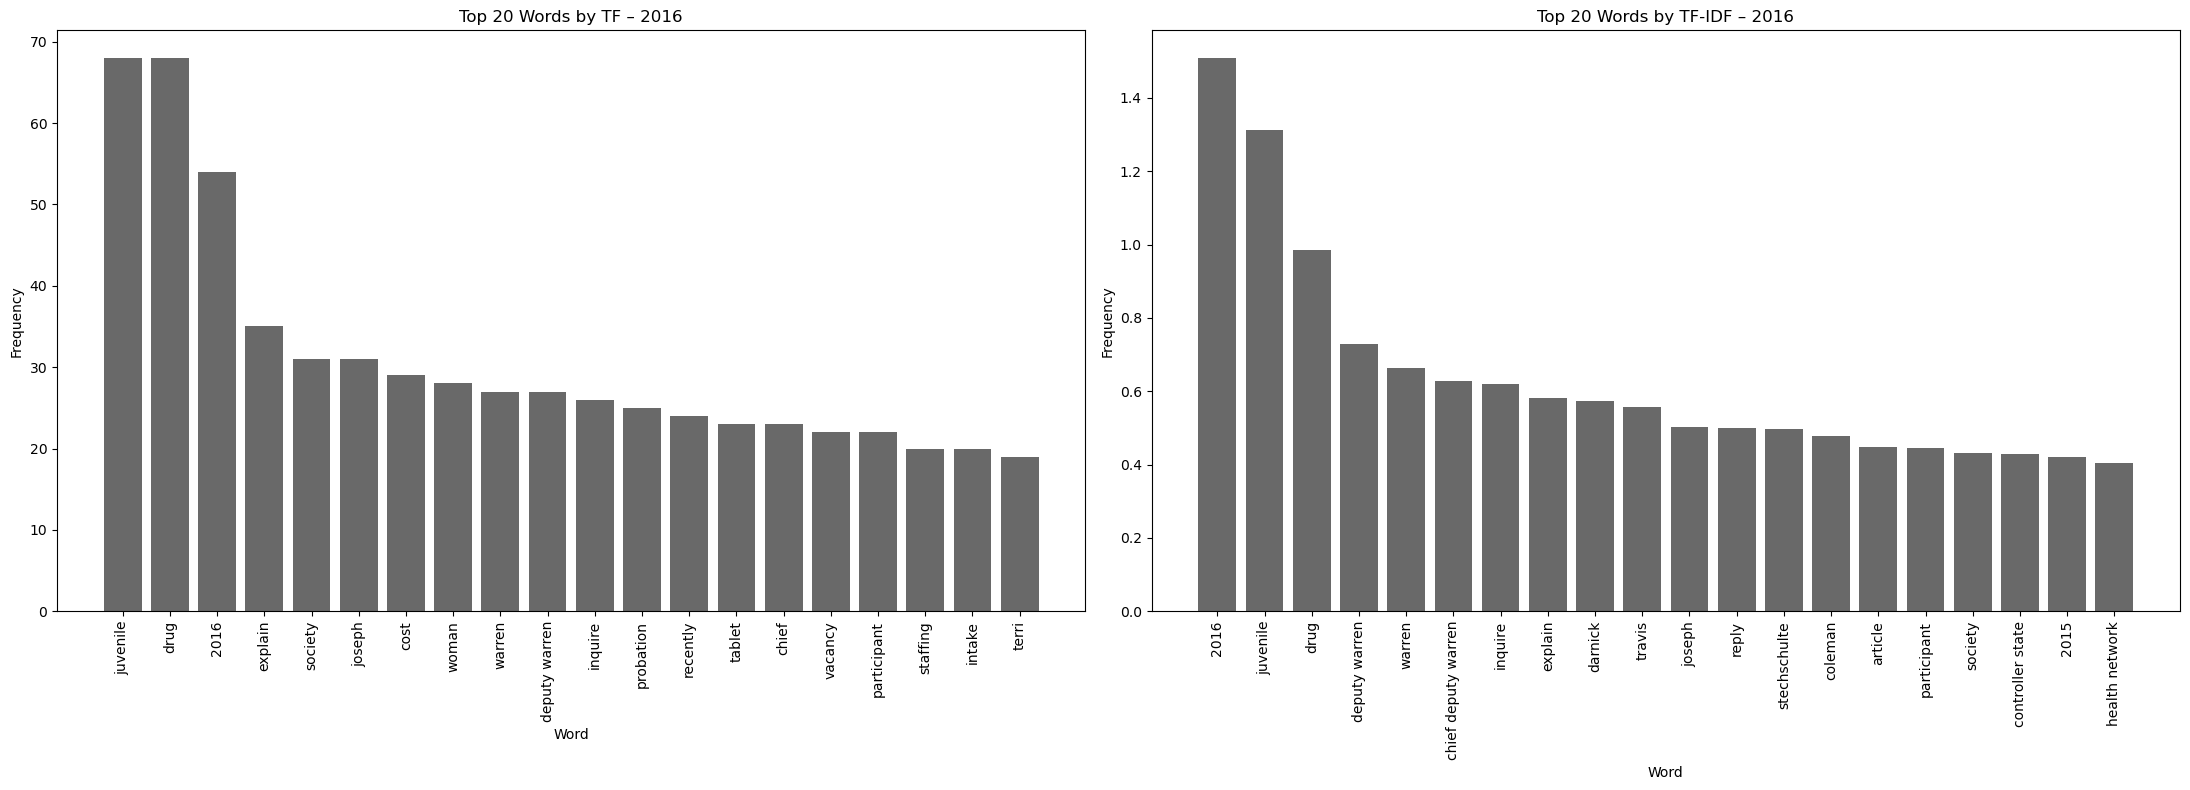

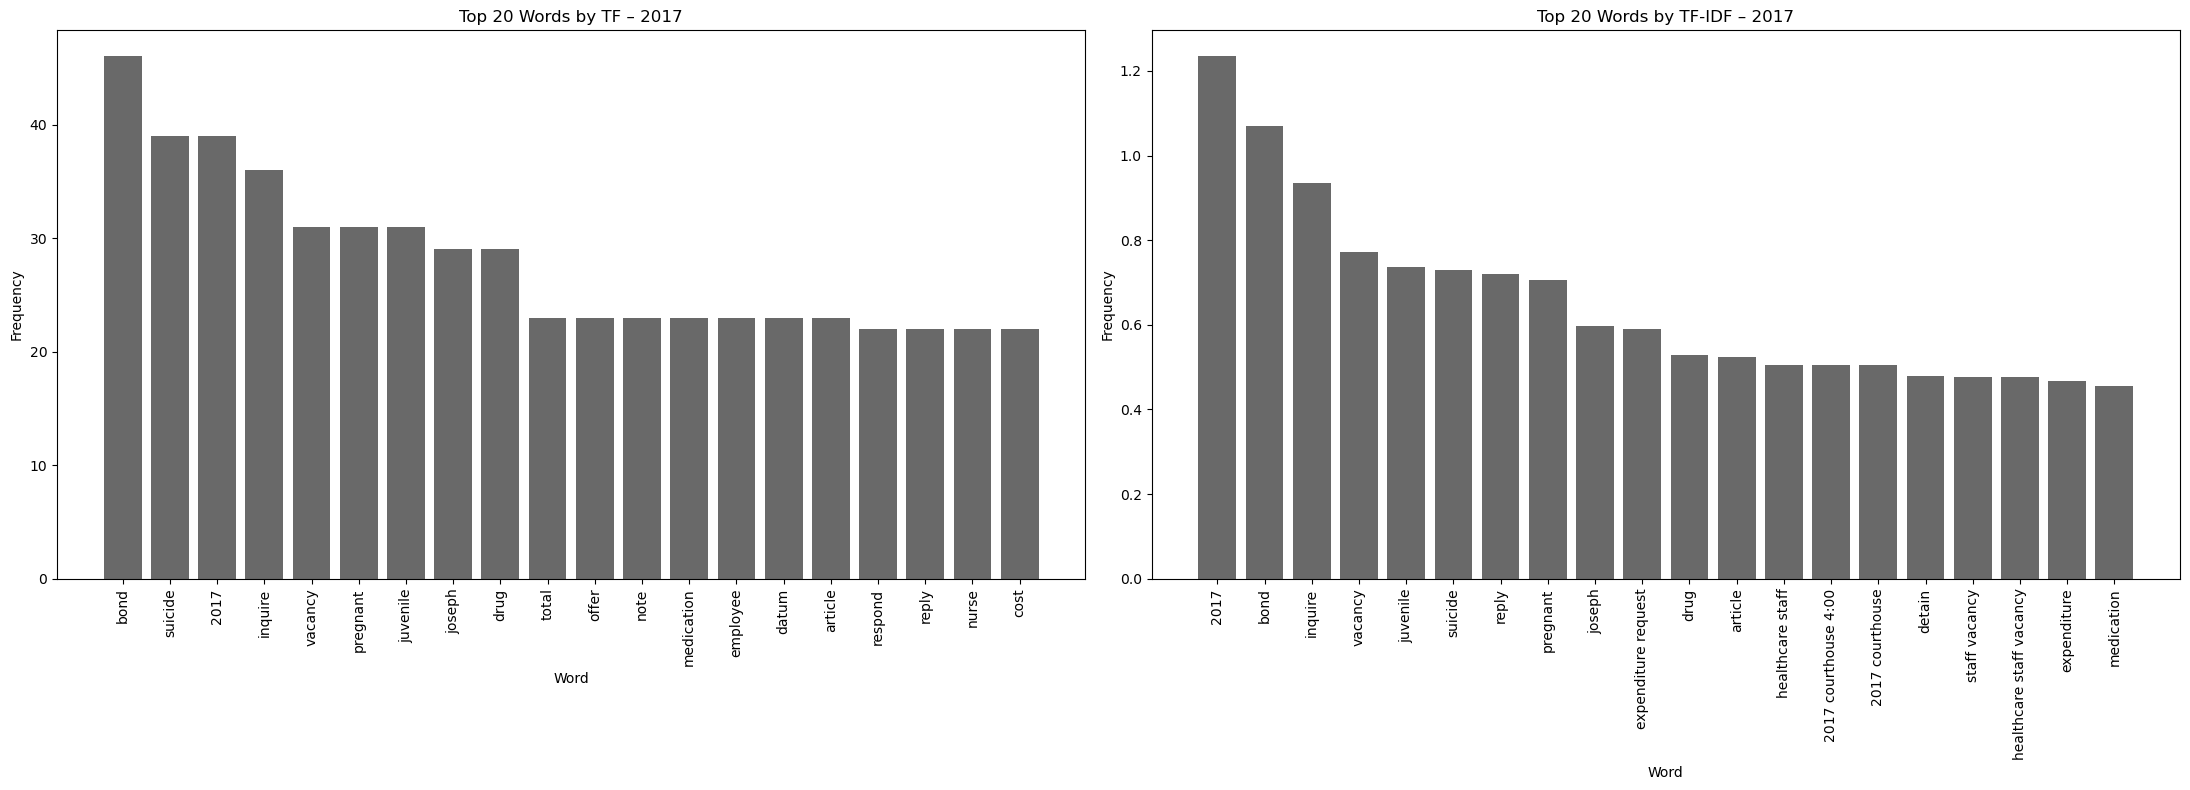

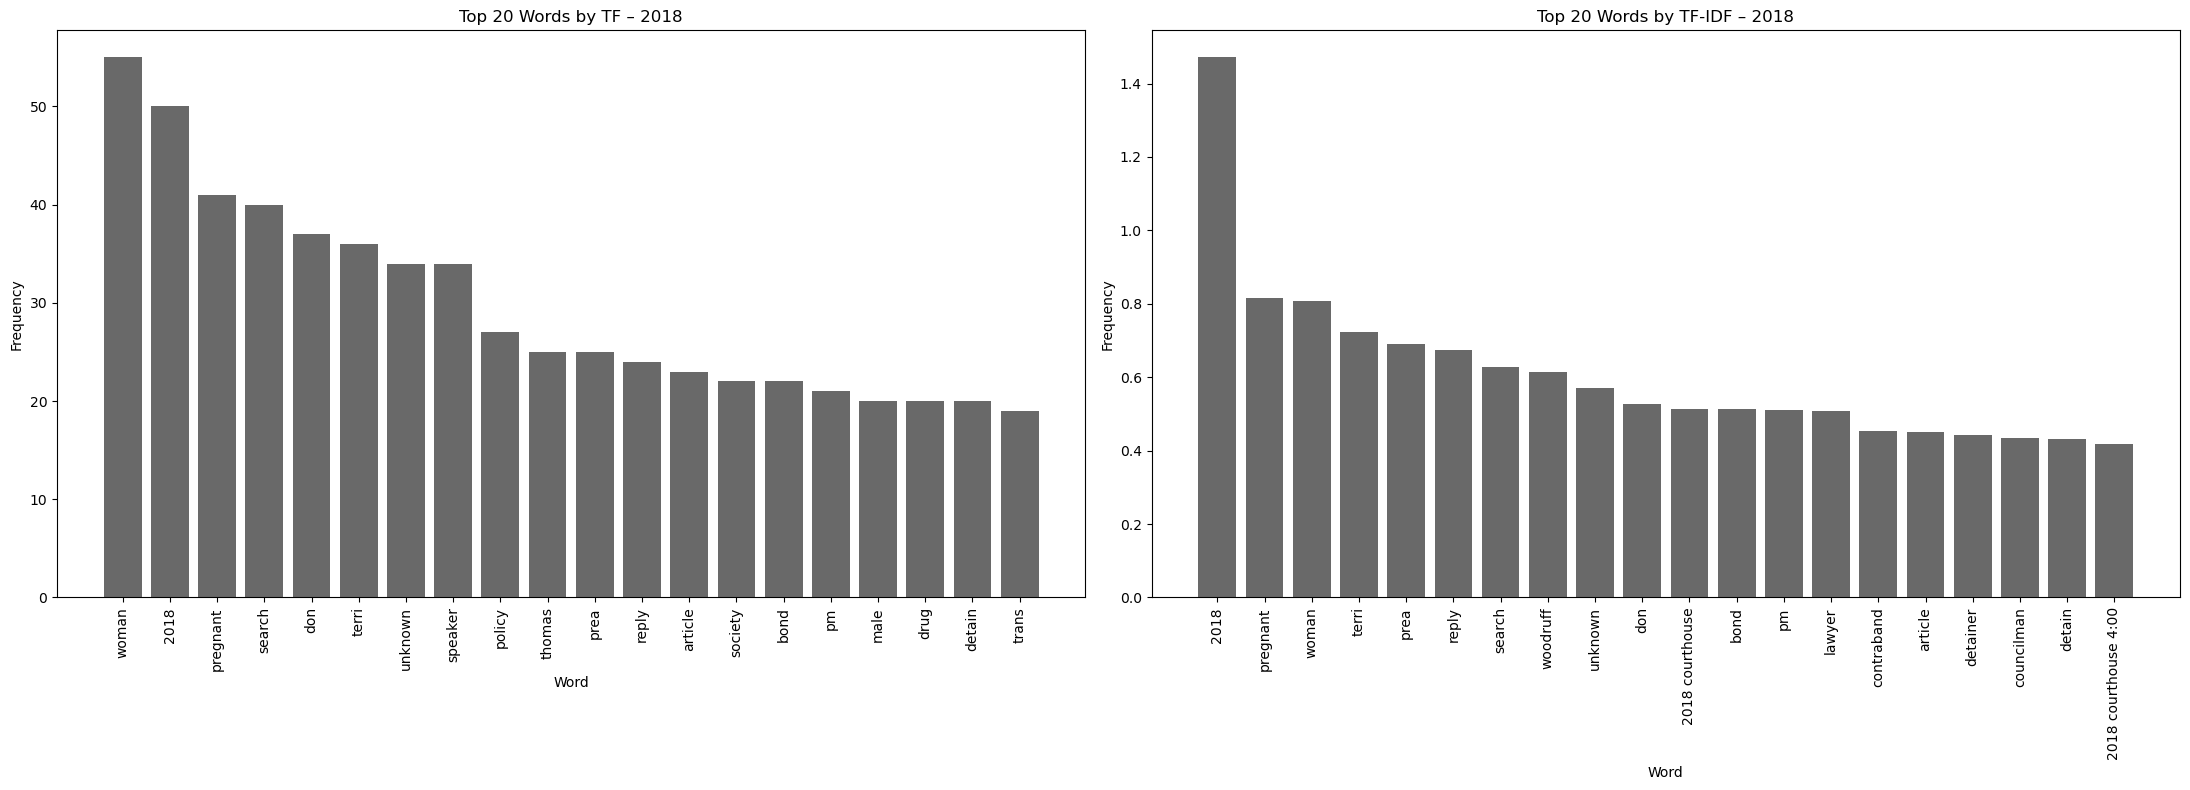

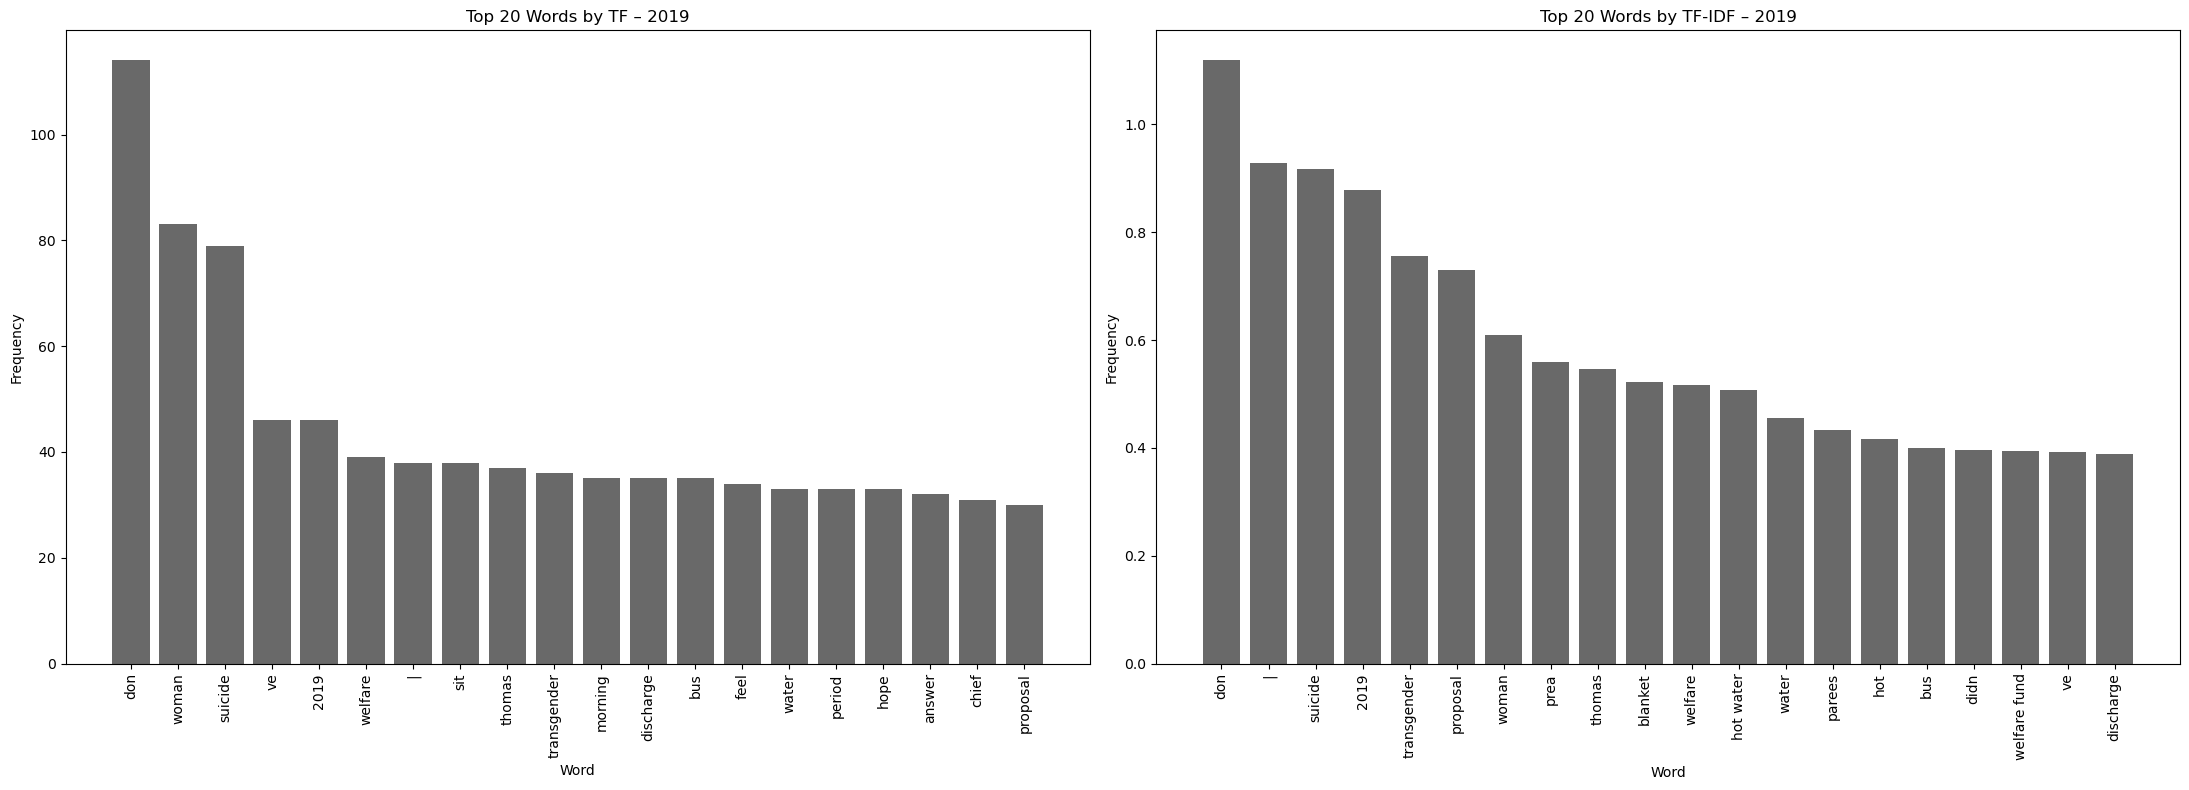

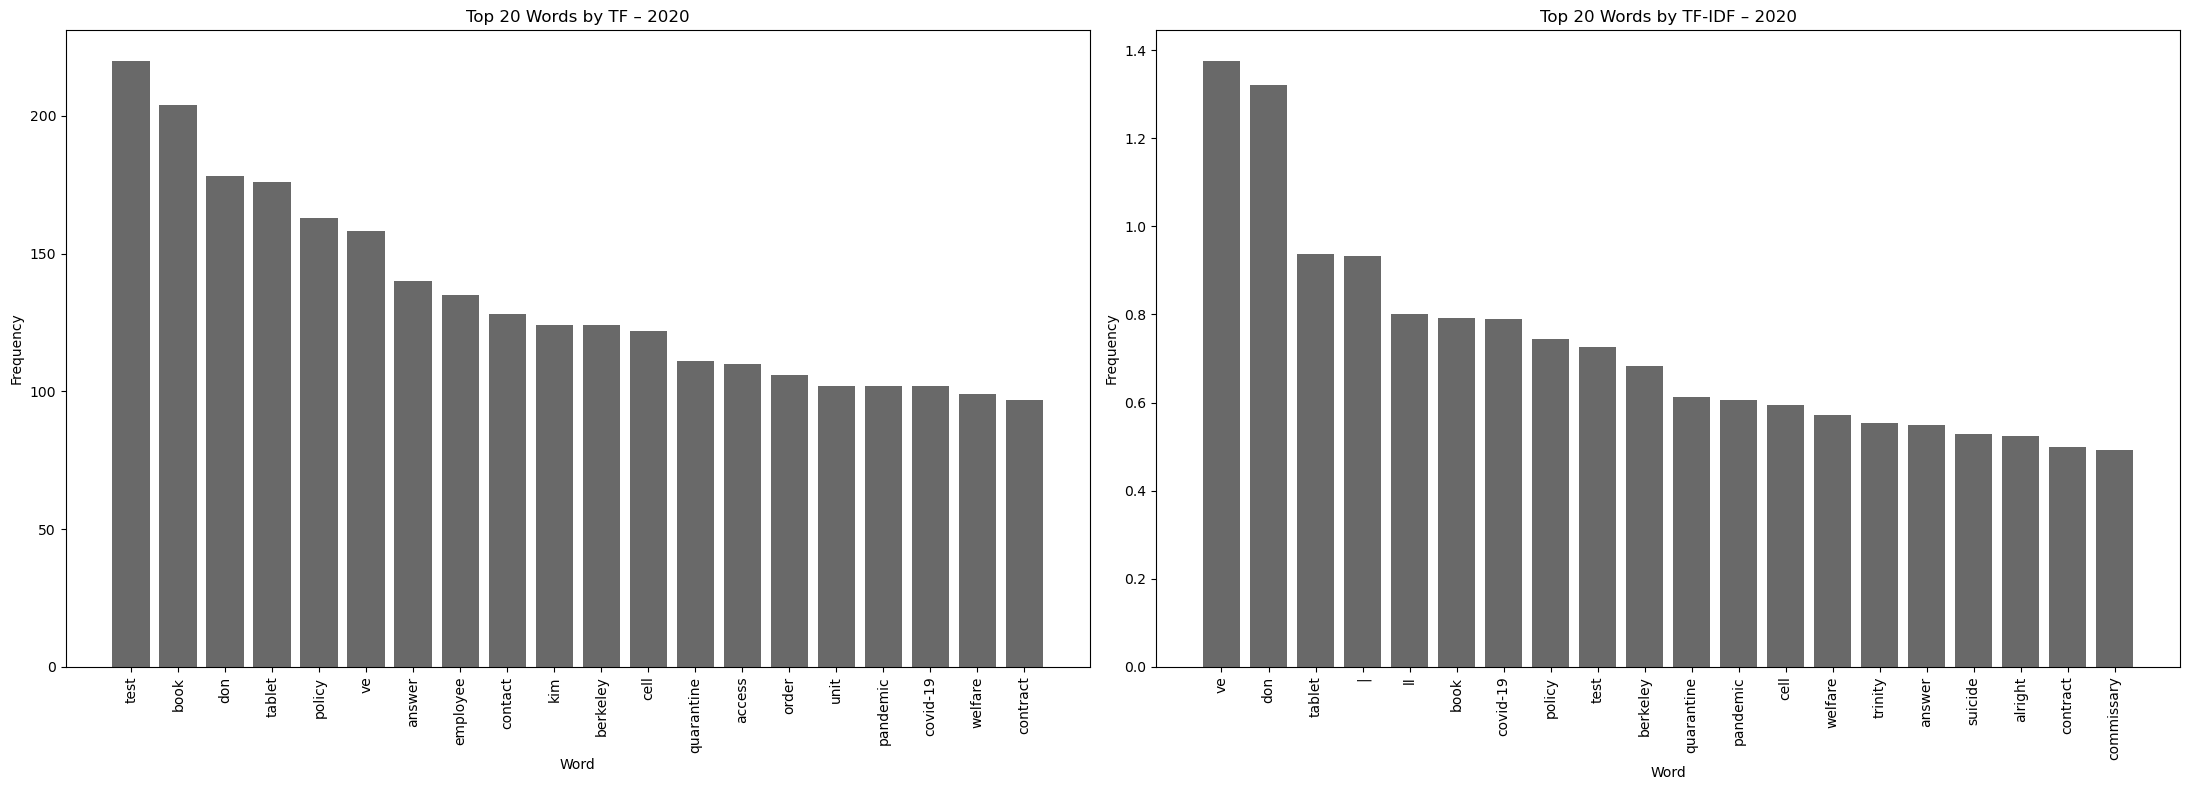

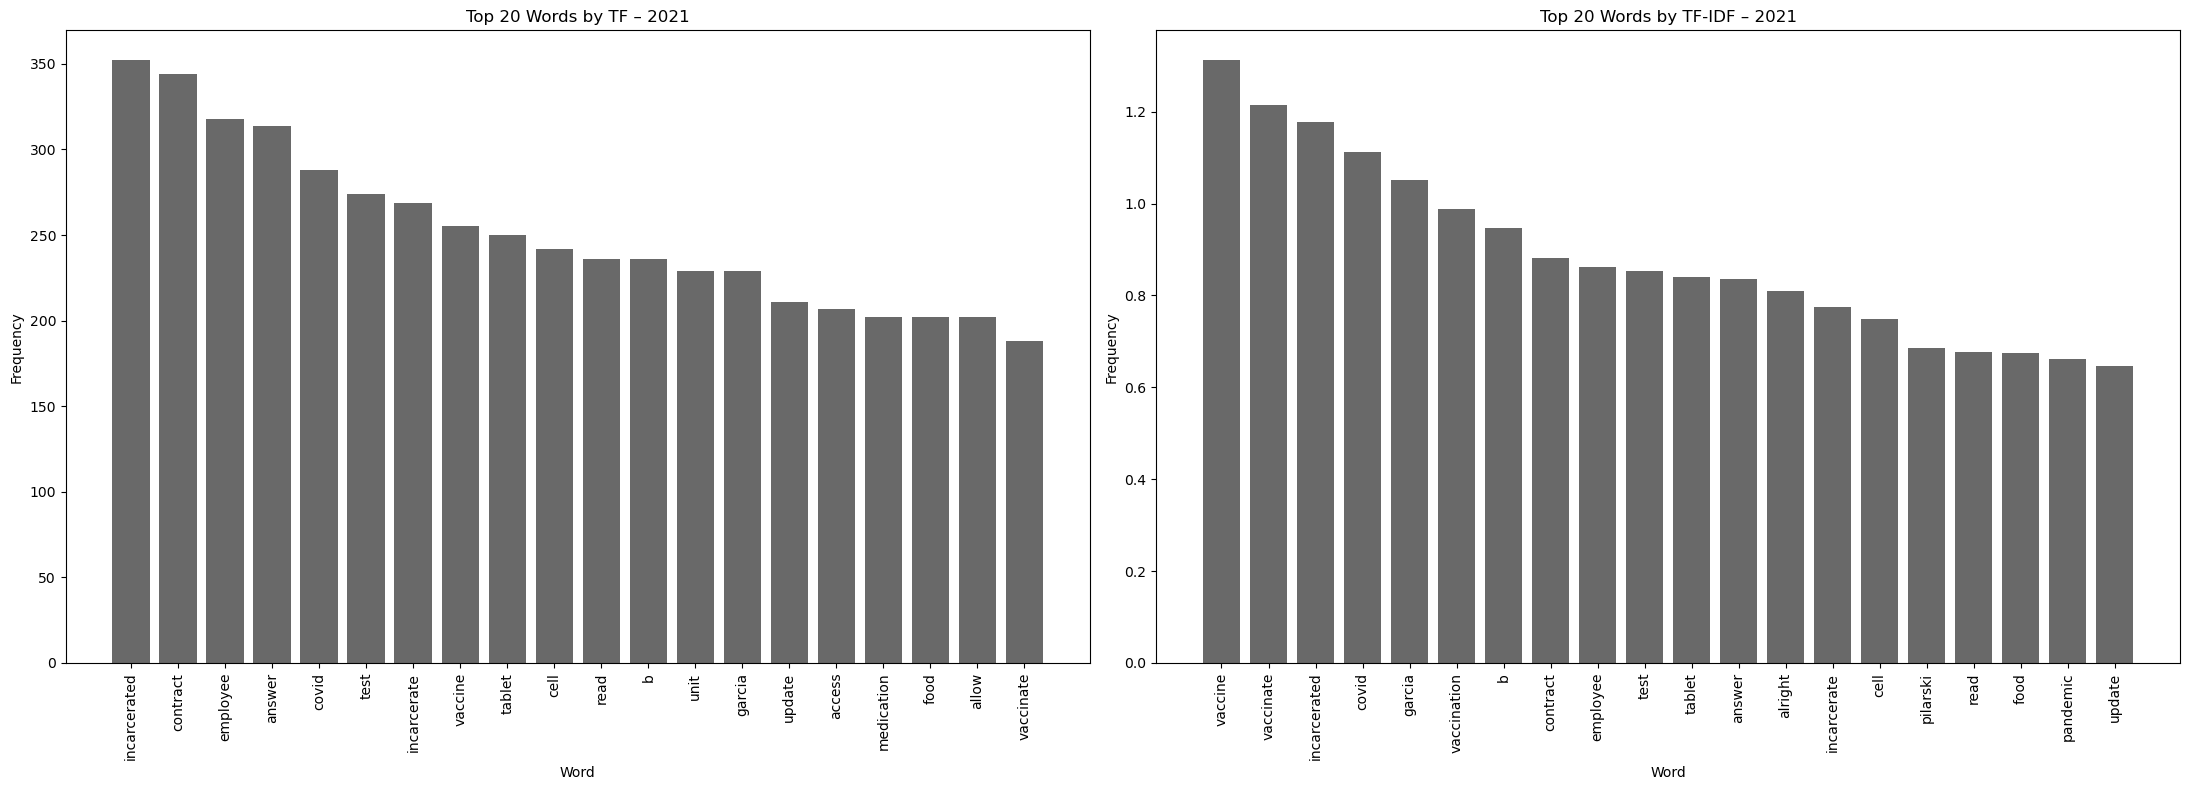

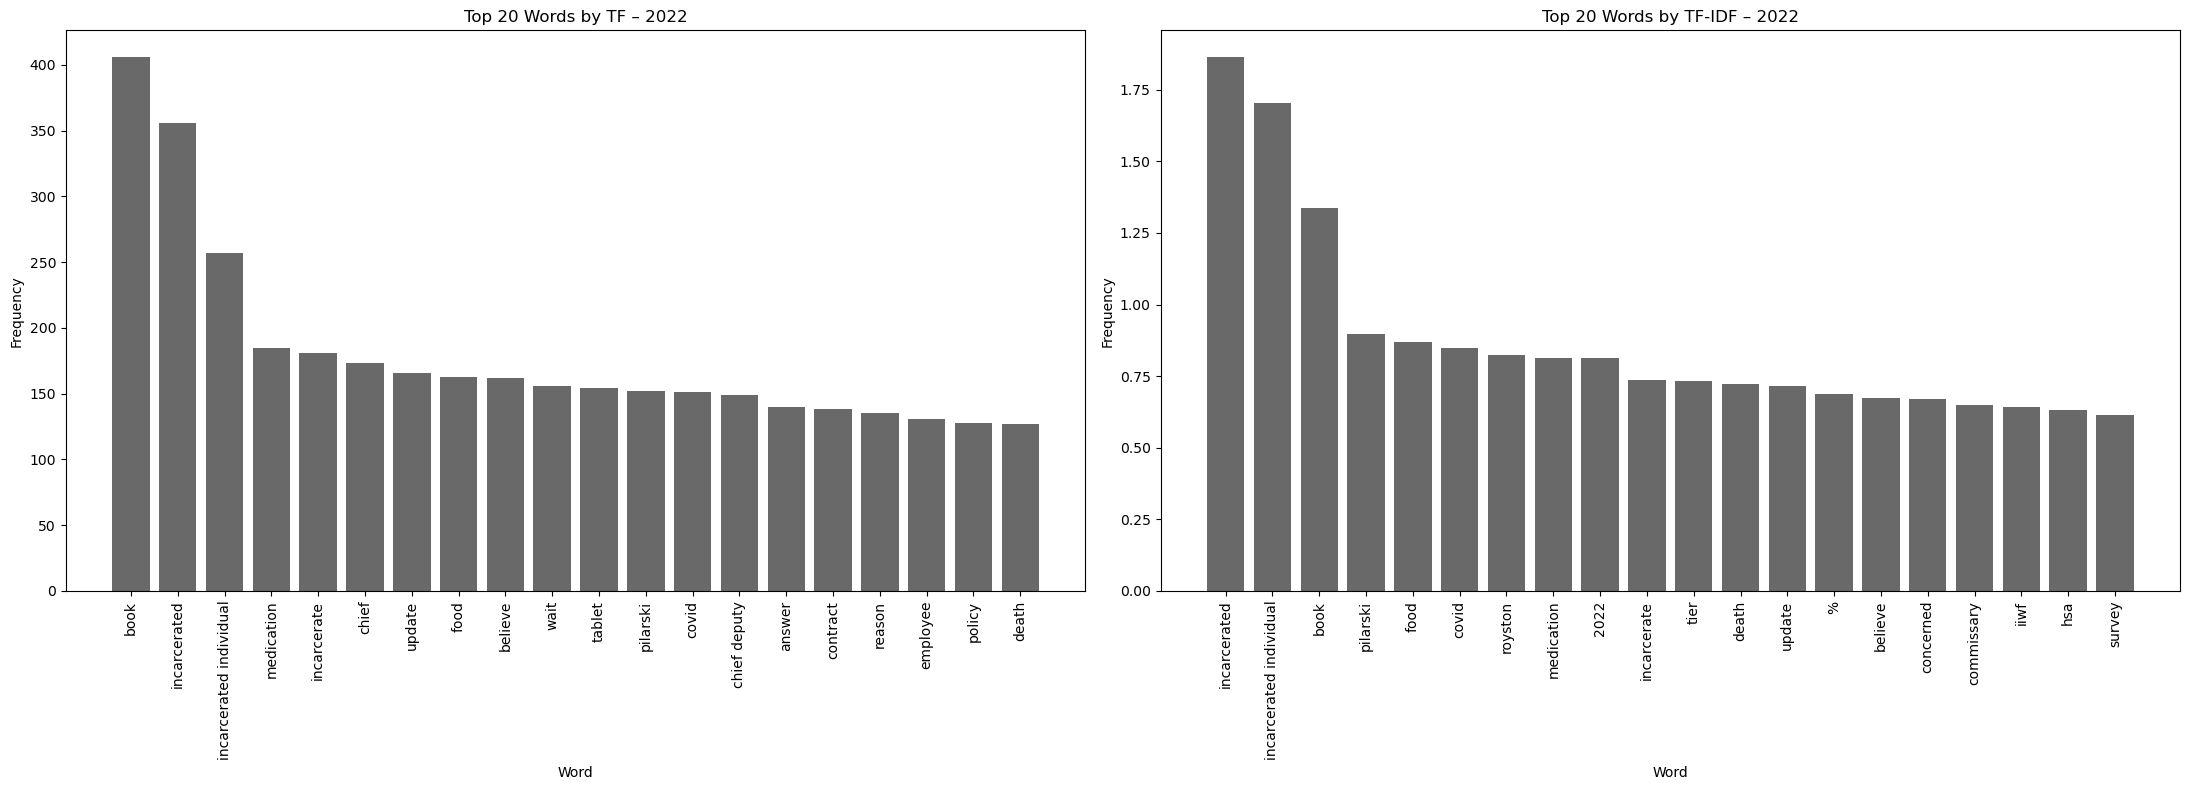

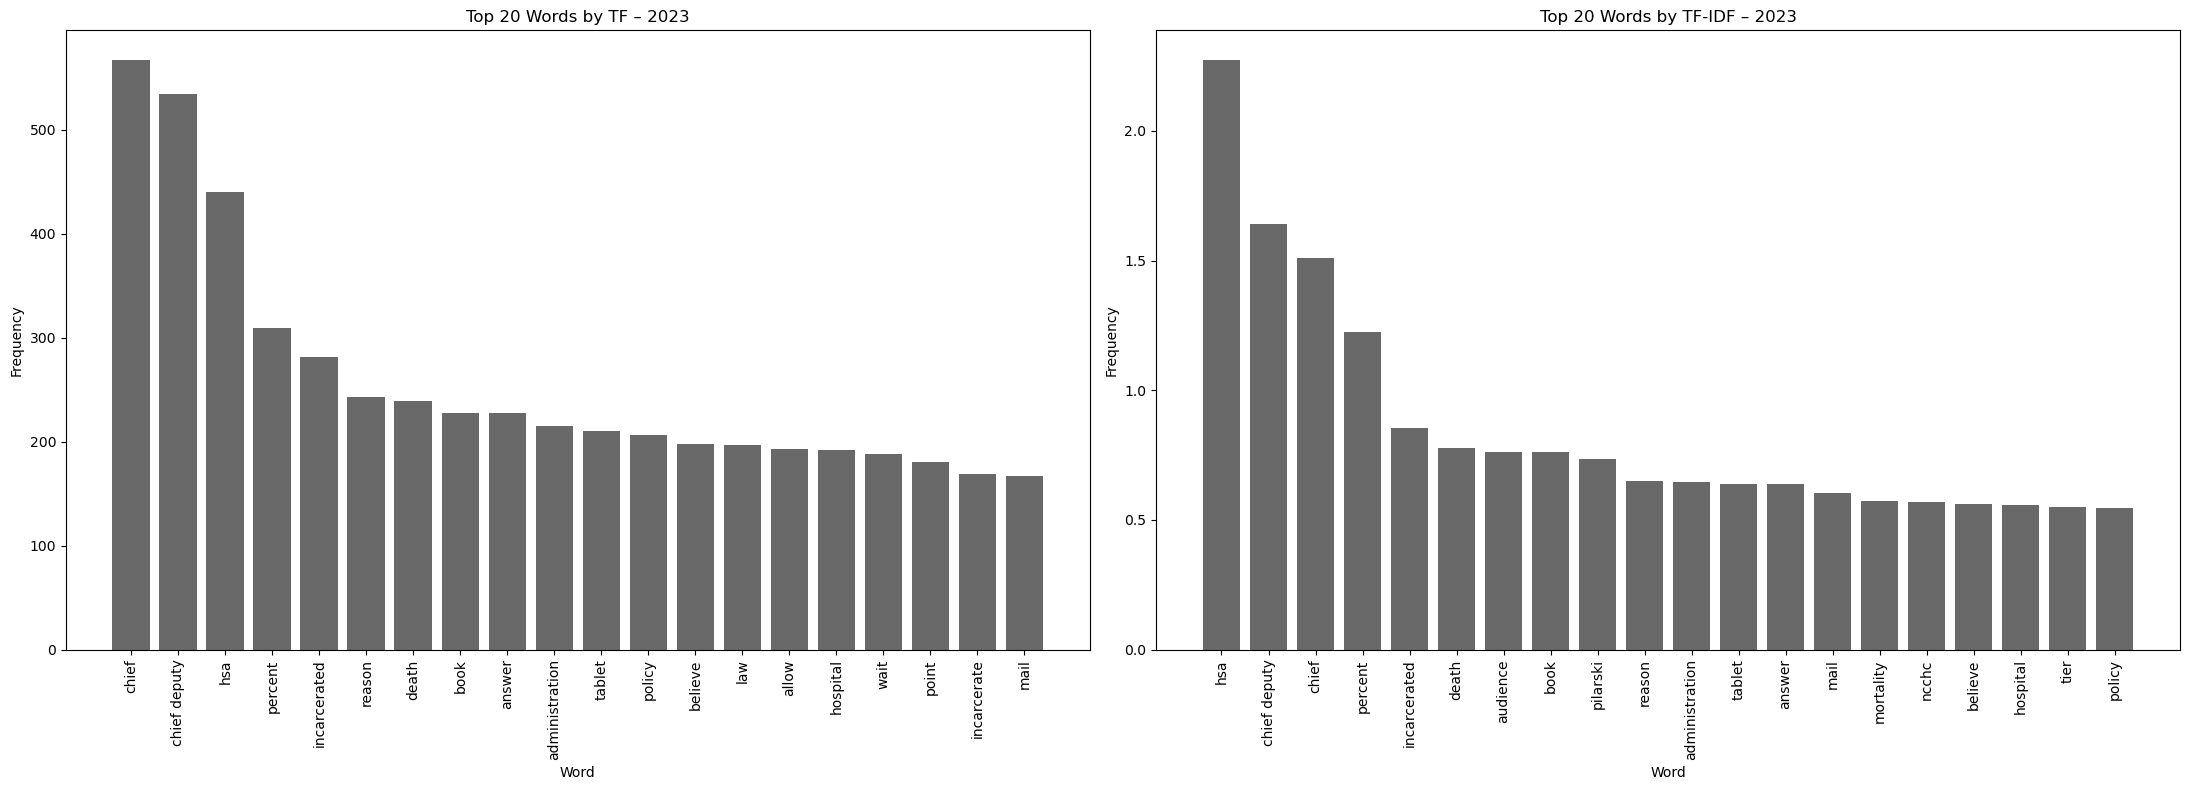

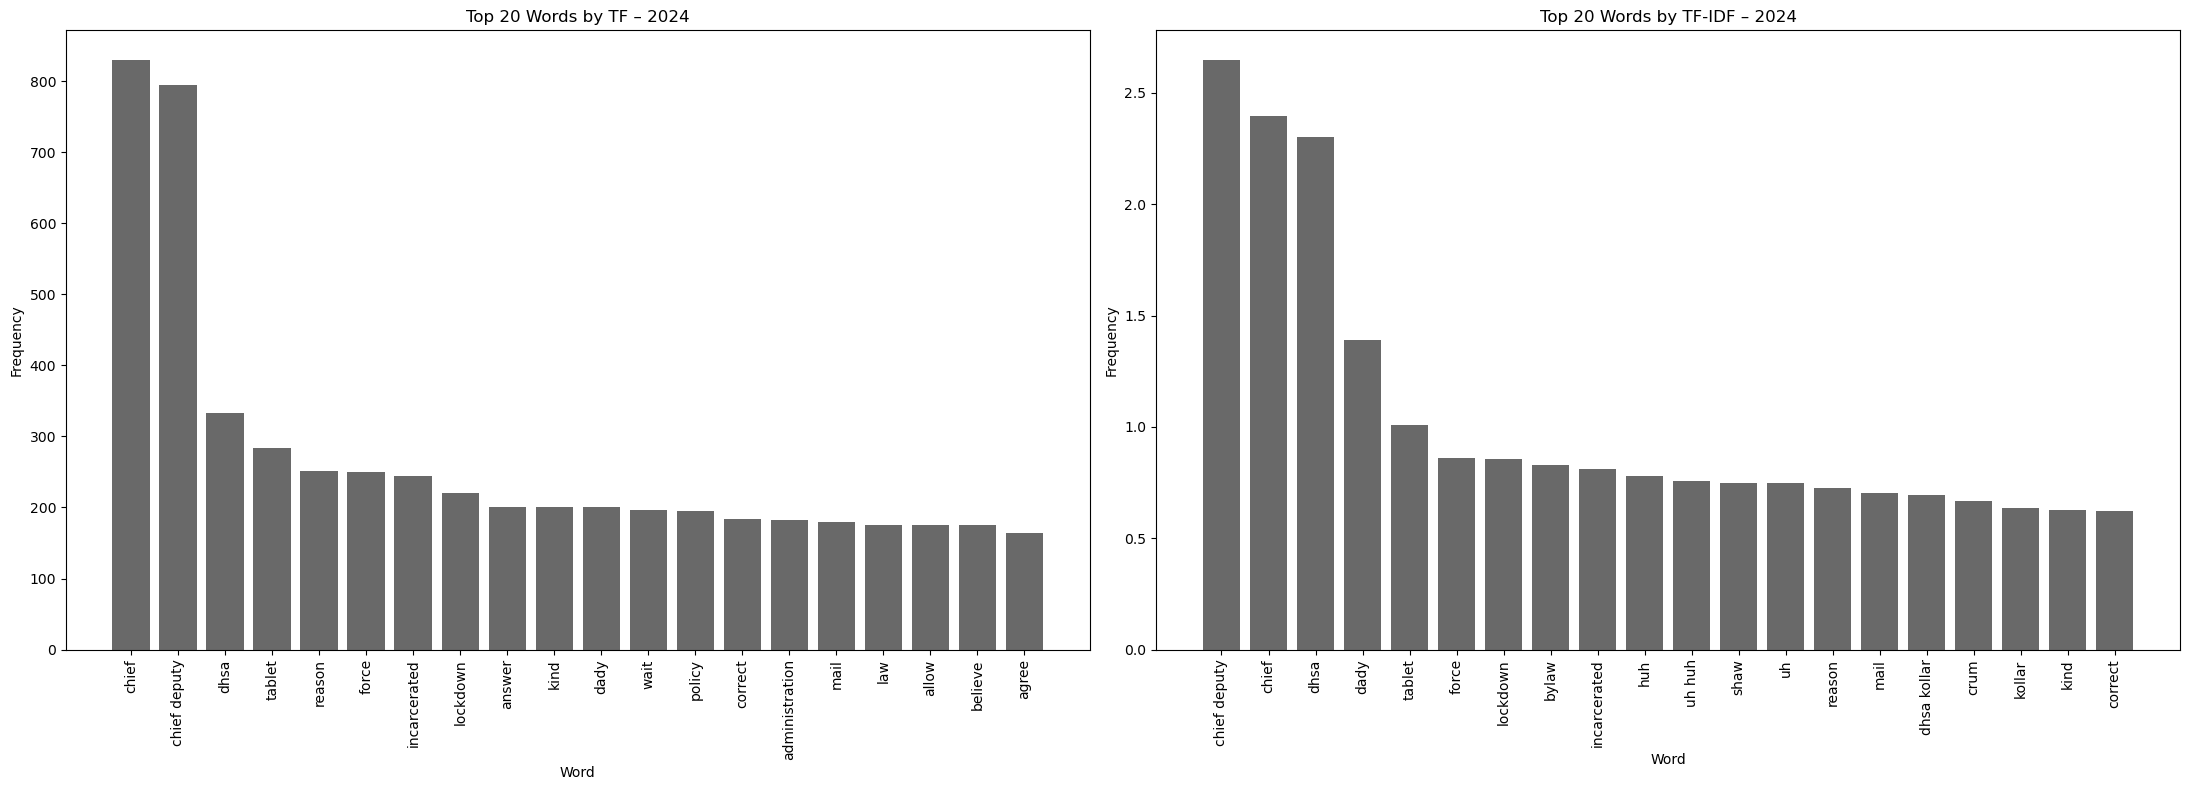

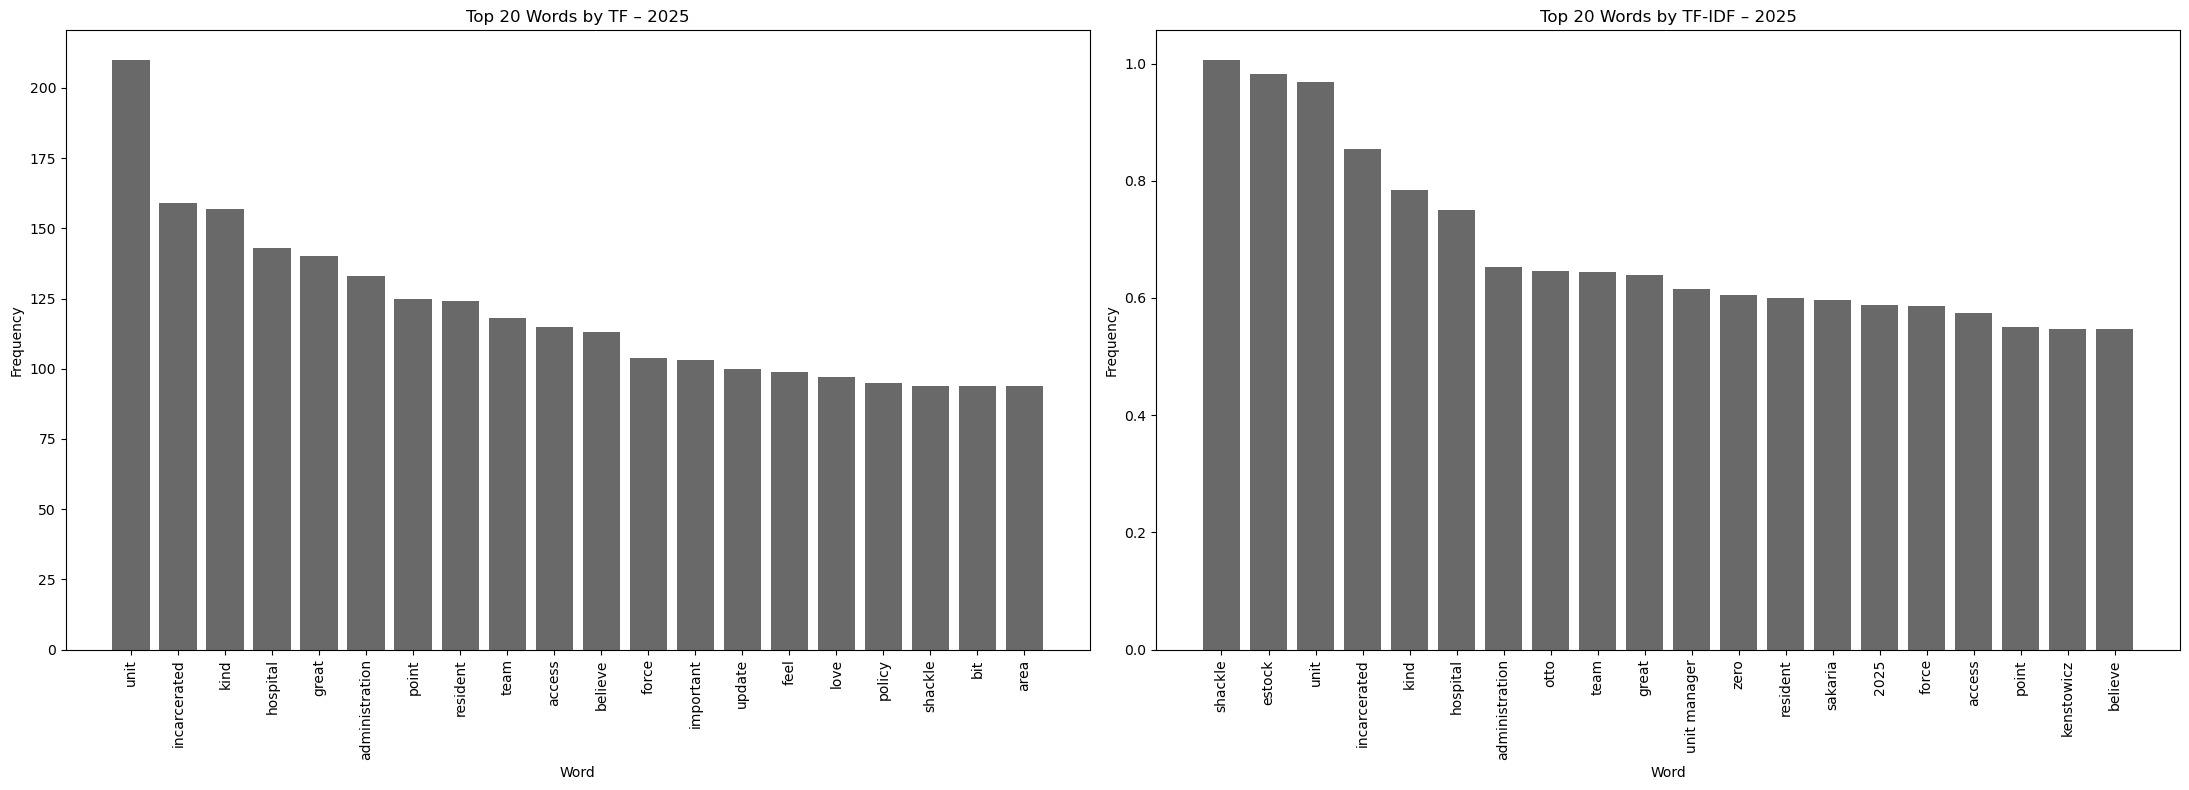

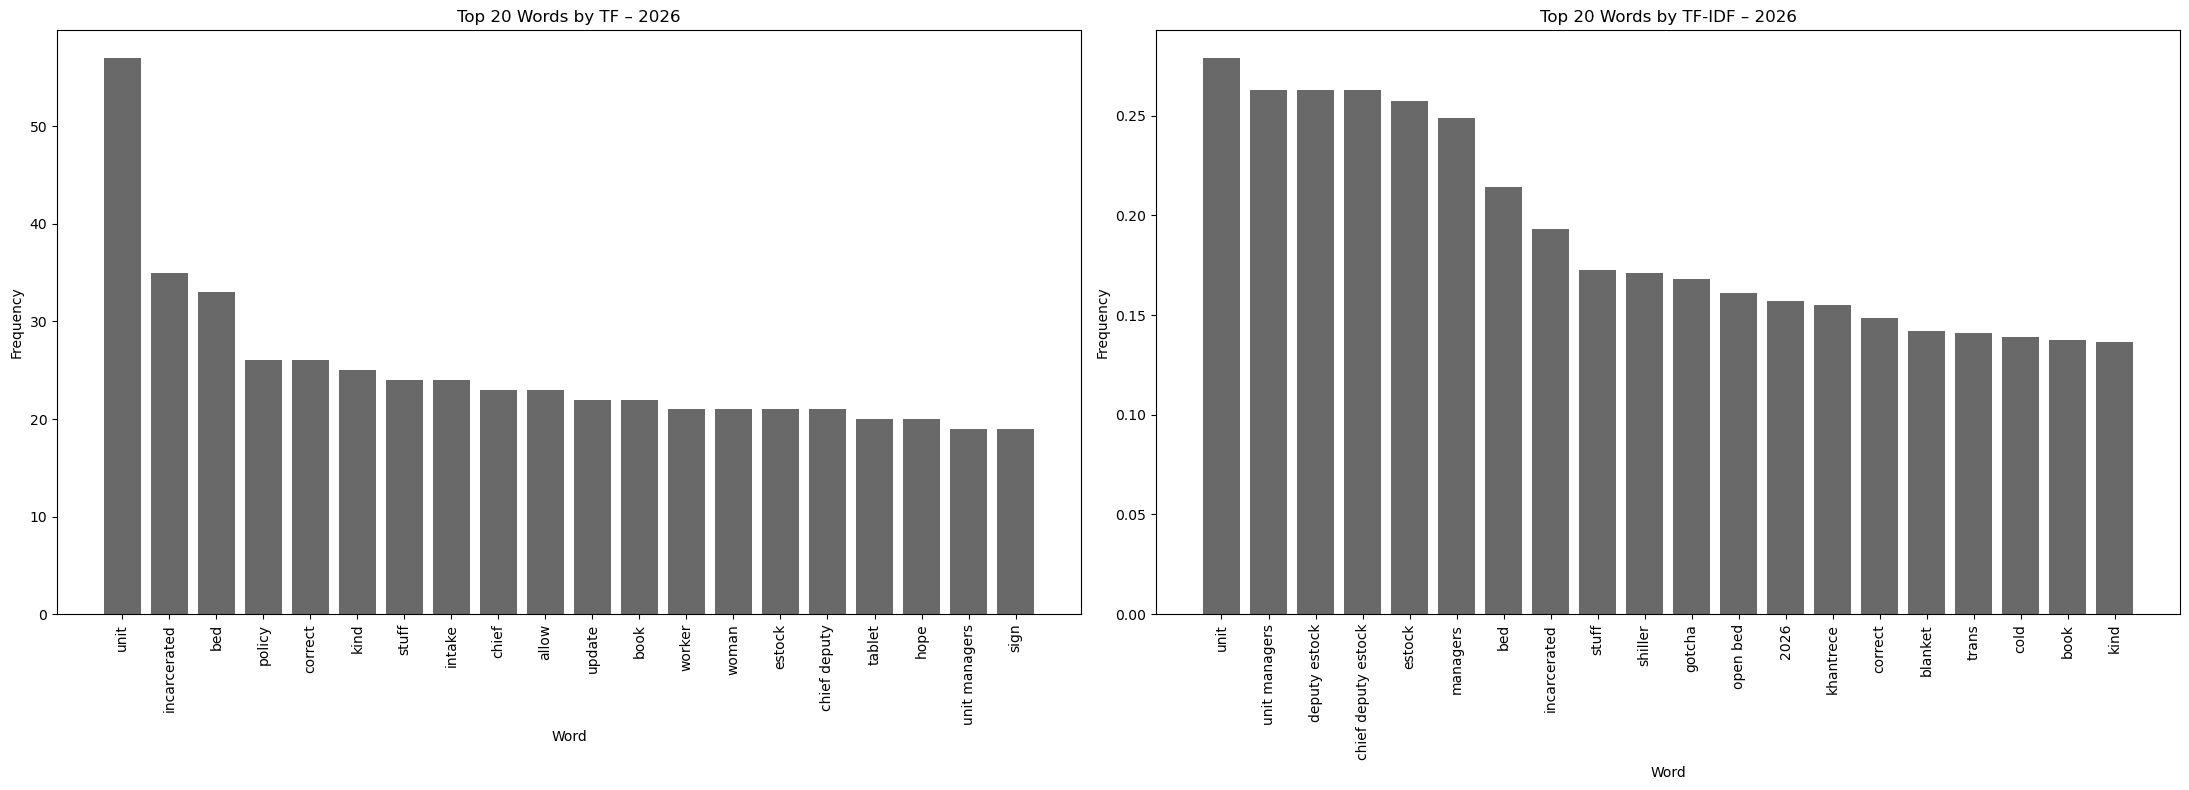

In [13]:
# Looping through each year and making tf and tf-idf plots
unique_years = sorted(df["year"].dropna().unique())

for yr in unique_years:
    year_docs = df.loc[df["year"] == yr, "document"].tolist()
    if not year_docs:
        continue

    tf_year = tf_vectorizer.transform(year_docs)
    tfidf_year = idf_transformer.transform(tf_year)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))

    plt.sca(ax1)
    plot_top_words(np.array(tf_year.sum(axis=0)).flatten(), vocab, num_top_words=20)
    ax1.set_title(f"Top 20 Words by TF – {int(yr)}")

    plt.sca(ax2)
    plot_top_words(np.array(tfidf_year.sum(axis=0)).flatten(), vocab, num_top_words=20)
    ax2.set_title(f"Top 20 Words by TF-IDF – {int(yr)}")

    plt.tight_layout()
    plt.show()

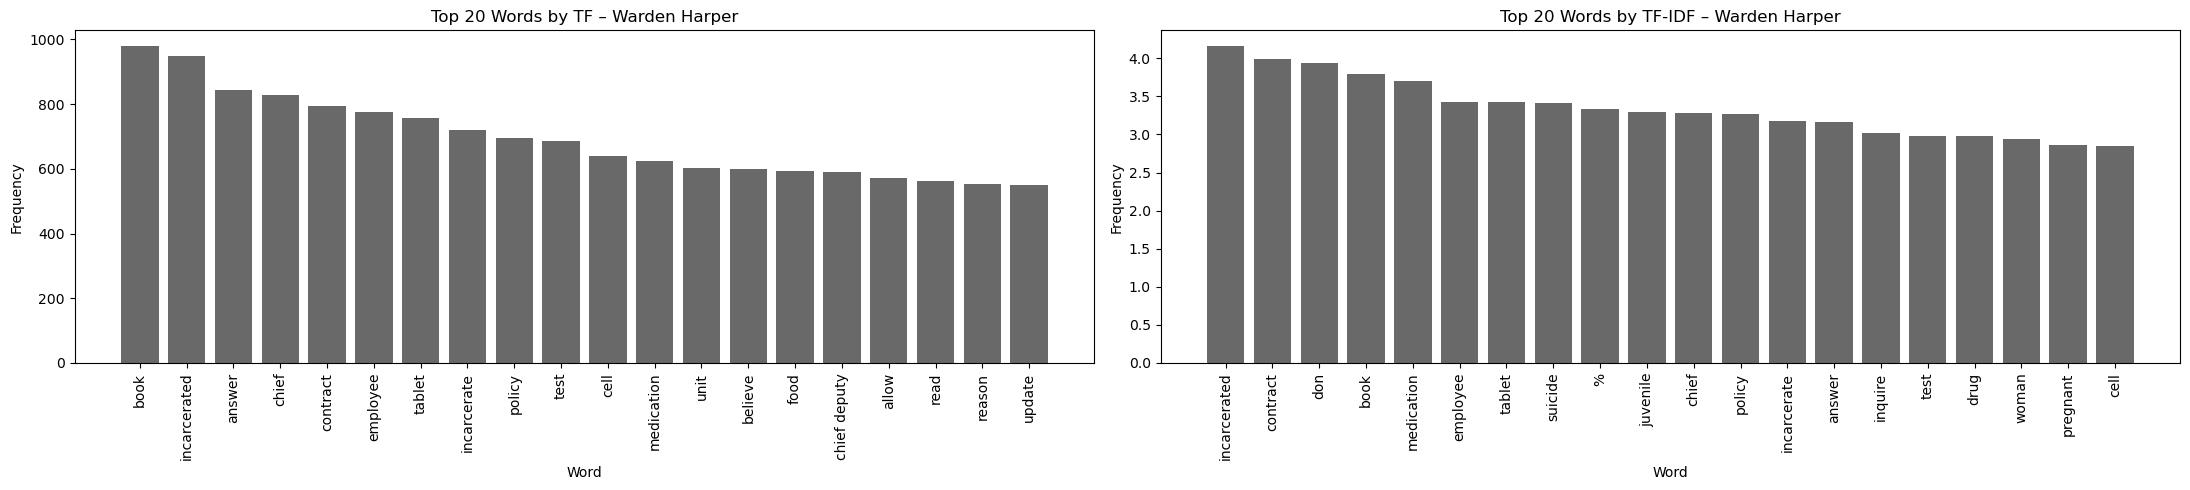

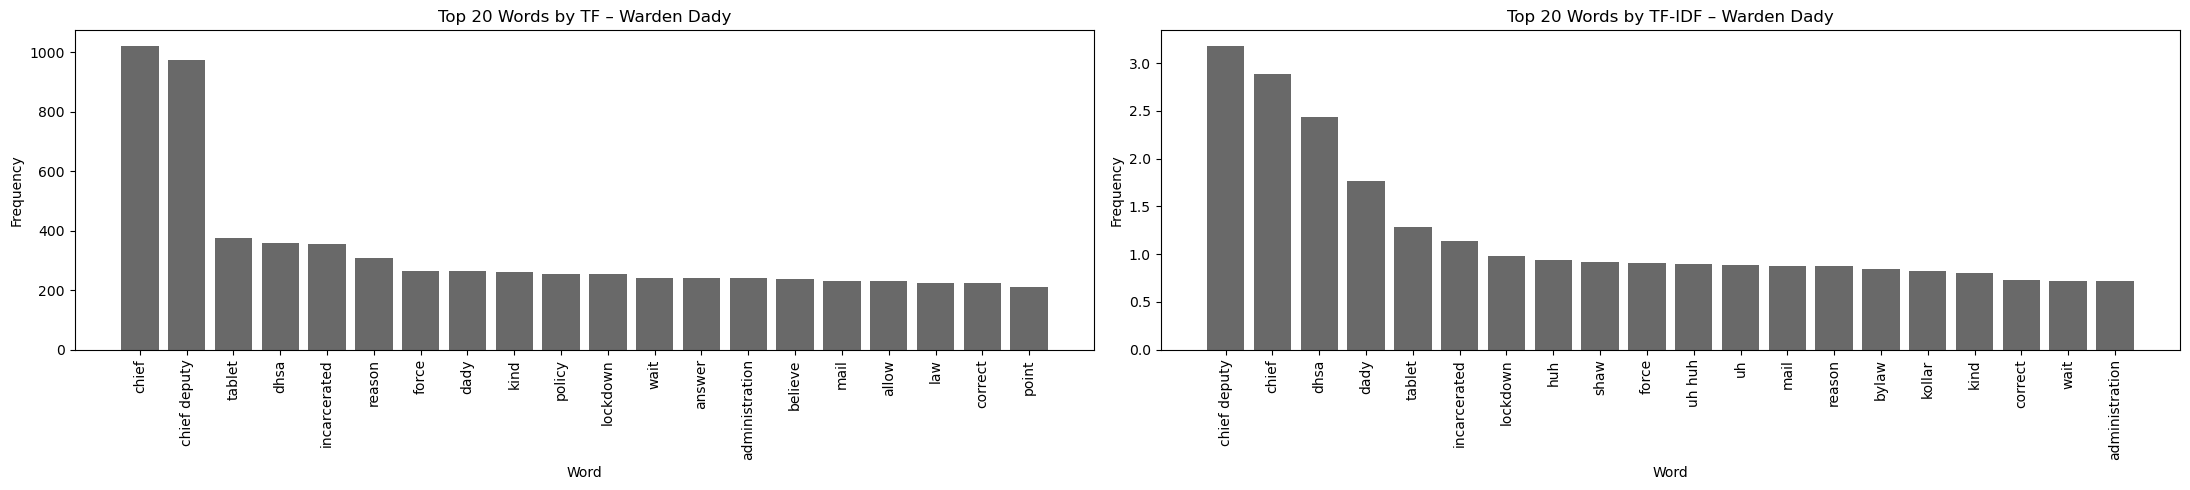

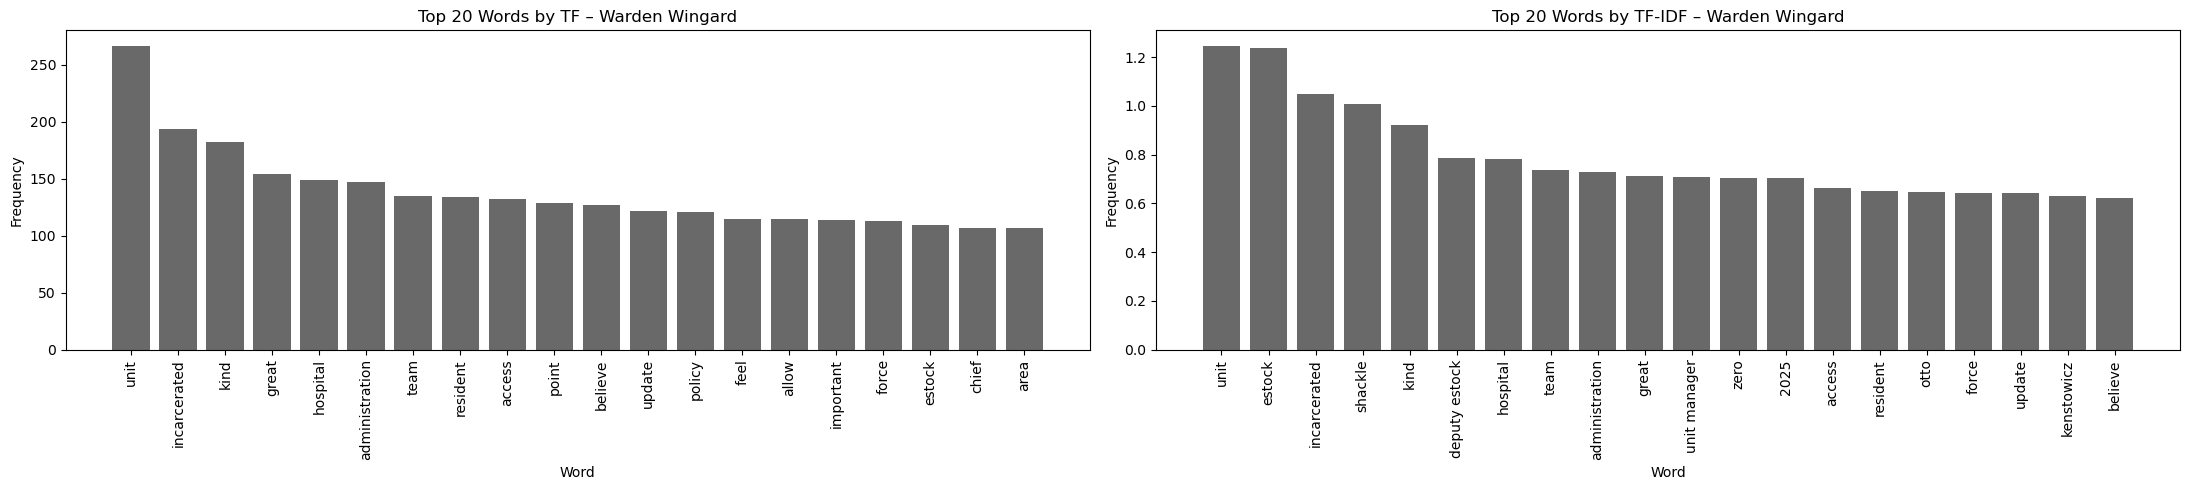

In [14]:
# Looping through each warden period to make tf and tf-idf plots
periods = ["Harper", "Dady", "Wingard"]

for period in periods:
    period_docs = df.loc[df["period"] == period, "document"].tolist()

    tf_period = tf_vectorizer.transform(period_docs)
    tfidf_period = idf_transformer.transform(tf_period)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 5))

    plt.sca(ax1)
    plot_top_words(np.array(tf_period.sum(axis=0)).flatten(), vocab, num_top_words=20)
    ax1.set_title(f"Top 20 Words by TF – Warden {period}")

    plt.sca(ax2)
    plot_top_words(np.array(tfidf_period.sum(axis=0)).flatten(), vocab, num_top_words=20)
    ax2.set_title(f"Top 20 Words by TF-IDF – Warden {period}")

    plt.tight_layout()
    plt.show()

### Looking at n-gram frequency over time

In [15]:
# Printing vocab list to find n-grams to track
print(list(vocab))
print('\n')

['%', '% %', '% employee', '% population', '% positive', '% receive', '% staff', '&', '& noble', '*', '+', '-19', '-assiste', '-assiste treatment', '-base', '-based', '-day', '-day lockdown', '-ended', '-in', '-line', '-line staff', '-making', '-on', '-ordere', '-out', '-relate', '-searche', '-searched', '-term', '-to', '-up', '-up question', '-wide', '-wide lockdown', '-year', '.com', '/client', '1,000', '1,500', '1,800', '1,859', '10,000', '100,000', '10:00', '10:30', '10th', '11:00', '11th', '12th', '13th', '13th amendment', '14th', '15th', '16th', '17th', '18th', '19th', '1:00', '1a', '1b', '1st', '2,000', '2,075', '2,500', '20,000', '2000', '2009', '2012', '2013', '2014', '2014 courthouse', '2014 courthouse 4:00', '2015', '2016', '2017', '2017 courthouse', '2017 courthouse 4:00', '2018', '2018 2019', '2018 courthouse', '2018 courthouse 4:00', '2019', '2020', '2021', '2021 concern', '2021 virtual', '2021 virtual 4:00', '2022', '2022 gold', '2023', '2023 gold', '2023 gold 4th', '202

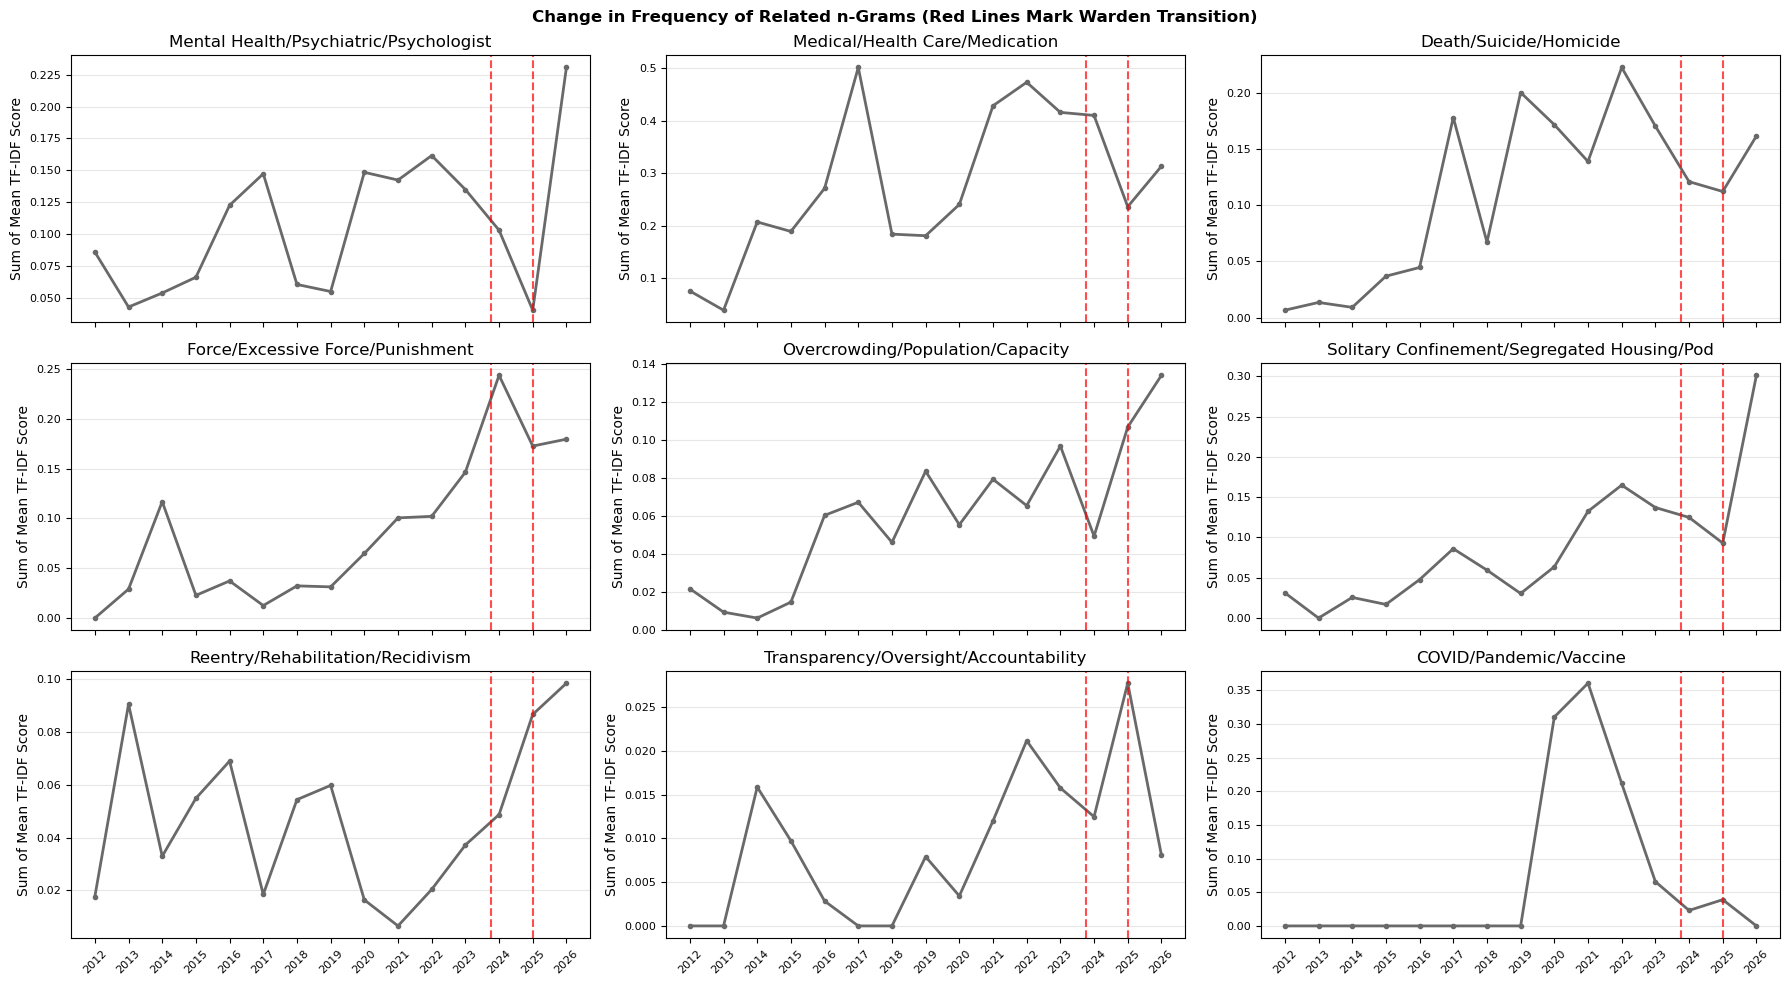

In [20]:
# Defining related n-grams
related_ngrams = {
    'Mental Health/Psychiatric/Psychologist': ['mental health', 'psychiatric', 'psychologist'],
    'Medical/Health Care/Medication': ['medical', 'healthcare', 'health care', 'medication'],
    'Death/Suicide/Homicide': ['death', 'suicide', 'homicide'],
    'Force/Excessive Force/Punishment': ['force','excessive force', 'punishment'],
    'Overcrowding/Population/Capacity': ['overcrowding', 'population', 'capacity'],
    'Solitary Confinement/Segregated Housing/Pod': ['solitary confinement', 'segregated housing', 'pod', 'pods'],
    'Reentry/Rehabilitation/Recidivism': ['reentry', 're-entry', 'rehabilitation', 'recidivism'],
    'Transparency/Oversight/Accountability': ['transparency','oversight','accountability'],
    'COVID/Pandemic/Vaccine': ['covid', 'pandemic', 'quarantine'],
}

# Returns indices of vocab terms that match any ngram for a given topic
def get_ngram_indices(group_ngrams, vocab):
    indices = []
    for i, v in enumerate(vocab):
        for kw in group_ngrams:
            if kw in v:
                indices.append(i)
    return indices

# Map each ngram to its matching vocab indices
ngram_indices = {}
for ngram, keywords in related_ngrams.items():
    idx = get_ngram_indices(keywords, vocab)
    ngram_indices[ngram] = idx

# Compute mean TF-IDF per ngram group per year
ngram_trends = pd.DataFrame(index=sorted(unique_years), columns=related_ngrams.keys(), dtype=float)

for yr in unique_years:
    year_docs = df.loc[df["year"] == yr, "document"].tolist()
    tf_yr = tf_vectorizer.transform(year_docs)
    tfidf_yr = idf_transformer.transform(tf_yr)
    mean_tfidf = np.array(tfidf_yr.mean(axis=0)).flatten()

    for ngrams, idx in ngram_indices.items():
        if idx:
            ngram_trends.loc[yr, ngrams] = mean_tfidf[idx].sum()
        else:
            ngram_trends.loc[yr, ngrams] = 0.0

# Plotting results and defining warden tenure
fig, axes = plt.subplots(3, 3, figsize=(18, 10), sharex=True)
axes = axes.flatten()

for i, group in enumerate(ngram_trends.columns):
    ax = axes[i]
    vals = ngram_trends[group]
    ax.plot(vals.index, vals, marker='o', markersize=3, linewidth=2, color='dimgrey')
    ax.set_title(group)
    ax.set_xticks(ngram_trends.index)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylabel('Sum of Mean TF-IDF Score')

    ax.axvline(x=2023.75, color='red', linestyle='--', alpha=0.7)
    ax.axvline(x=2025, color='red', linestyle='--', alpha=0.7)


fig.suptitle('Change in Frequency of Related n-Grams (Red Lines Mark Warden Transition)', fontweight='bold')

plt.tight_layout()
plt.show()